# KNN Variants for Class Imbalance — ML1 Practical Assignment 2025/2026

**Machine Learning I (CC2008) — University of Porto**

---

All algorithm logic lives in `src/`. Cells here only call functions and display results.

### Contents
1. [Setup & Imports](#1-setup--imports)
2. [Data Loading and Exploration](#2-data-loading-and-exploration)
3. [Baseline Evaluation](#3-baseline-evaluation)
4. [Proposed Variants](#4-proposed-variants)
5. [Benchmarking and Comparison](#5-benchmarking-and-comparison)
6. [Statistical Analysis](#6-statistical-analysis)
7. [Conclusions](#7-conclusions)

---
## 1. Setup & Imports

In [1]:
import sys
from pathlib import Path

# Make src/ importable when running from notebooks/
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from src.utils.config import load_config, get_project_root
from src.data.loader import load_all_datasets
from src.data.preprocessing import binarise_labels, remove_constant_features, standardise
from src.algorithms import KNNClassifier, KNNClassifierFast, KNNOptK
from src.evaluation.metrics import compute_all_metrics

cfg = load_config()
SEED = cfg["random_seed"]
rng = np.random.default_rng(SEED)

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

FIG_DIR = get_project_root() / cfg["paths"]["results_figures"]
TAB_DIR = get_project_root() / cfg["paths"]["results_tables"]
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")
print(f"Quick run mode: {cfg.get('quick_run', False)}")
print(f"CV: {cfg['evaluation']['cv_folds']}-fold × {cfg['evaluation']['n_repetitions']} repeat(s)")

Setup complete.
Quick run mode: False
CV: 10-fold × 1 repeat(s)


---
## 2. Data Loading and Exploration

In [2]:
datasets = load_all_datasets()
print(f"Loaded {len(datasets)} datasets after filtering.")

/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


Loaded 49 datasets after filtering.


/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


In [3]:
# Summary table
rows = []
for ds in datasets:
    y_bin = binarise_labels(ds.y)
    minority = int(y_bin.sum())
    majority = int((y_bin == 0).sum())
    rows.append({
        "dataset": ds.name,
        "n_samples": len(ds.y),
        "n_features": ds.X.shape[1],
        "minority": minority,
        "majority": majority,
        "IR": round(ds.imbalance_ratio, 4),
    })

summary = pd.DataFrame(rows).sort_values("IR")
print(f"IR range: {summary['IR'].min():.4f} – {summary['IR'].max():.4f}")
summary

IR range: 0.0072 – 0.2414


,dataset,n_samples,n_features,minority,majority,IR
14,dataset_1056_mc1,9466,38,68,9398,0.0072
21,dataset_316_yeast_ml8,2417,116,34,2383,0.0143
36,dataset_951_arsenic-male-lung,559,4,13,546,0.0238
35,dataset_950_arsenic-female-lung,559,4,19,540,0.0352
33,dataset_947_arsenic-male-bladder,559,4,24,535,0.0449
19,dataset_311_oil_spill,937,49,41,896,0.0458
11,dataset_1045_kc1-top5,145,94,8,137,0.0584
22,dataset_38_sick,3772,54,231,3541,0.0652
6,dataset_1018_ipums_la_99-small,8844,148,568,8276,0.0686
3,dataset_1013_analcatdata_challenger,138,2,9,129,0.0698


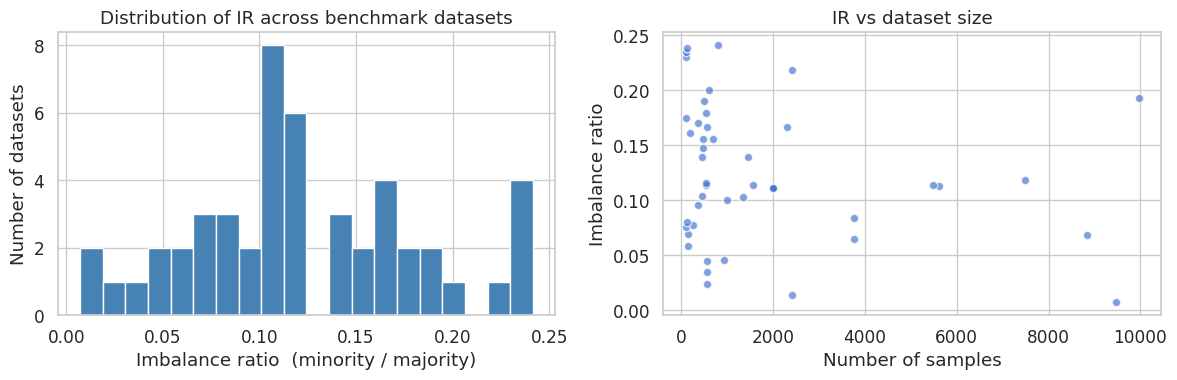

Datasets with IR < 0.1 (high imbalance): 15
Datasets with IR < 0.2: 43


In [4]:
# Distribution of imbalance ratios
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(summary["IR"], bins=20, edgecolor="white", color="steelblue")
axes[0].set_xlabel("Imbalance ratio  (minority / majority)")
axes[0].set_ylabel("Number of datasets")
axes[0].set_title("Distribution of IR across benchmark datasets")

axes[1].scatter(summary["n_samples"], summary["IR"], alpha=0.7, edgecolors="white")
axes[1].set_xlabel("Number of samples")
axes[1].set_ylabel("Imbalance ratio")
axes[1].set_title("IR vs dataset size")

plt.tight_layout()
fig.savefig(FIG_DIR / "dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Datasets with IR < 0.1 (high imbalance): {(summary['IR'] < 0.1).sum()}")
print(f"Datasets with IR < 0.2: {(summary['IR'] < 0.2).sum()}")

---
## 3. Baseline Evaluation

### 3.1  Why does standard KNN fail under class imbalance?

**Hypothesis:** KNN uses a majority vote among the $k$ nearest neighbours.  
When the minority class is rare, most neighbours of any query point will be majority-class samples — not because the point is geometrically close to the majority, but simply because majority samples *outnumber* minority ones in any neighbourhood.

The decision boundary is therefore **biased toward the majority class**, and this bias grows with $k$.  
Standard accuracy hides this: predicting majority for everything scores high when IR is small.

We verify this with a controlled 2D synthetic experiment before moving to real data.

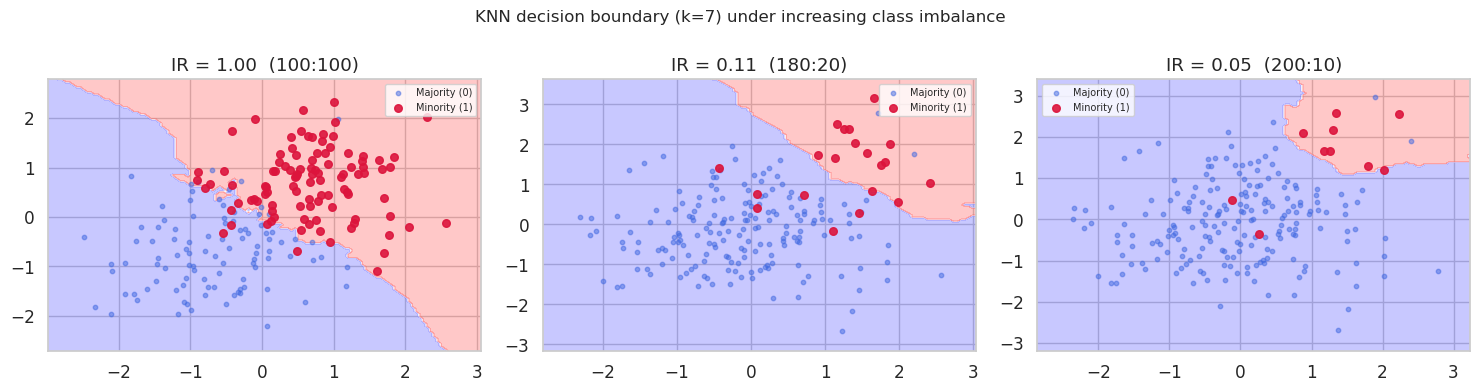

In [5]:
# ── Synthetic 2D experiment: visualise the bias ─────────────────────────────

def make_imbalanced_2d(n_majority, n_minority, seed=42):
    rng = np.random.default_rng(seed)
    X_maj = rng.multivariate_normal([0, 0], [[1, 0], [0, 1]], n_majority)
    X_min = rng.multivariate_normal([1.5, 1.5], [[0.6, 0], [0, 0.6]], n_minority)
    X = np.vstack([X_maj, X_min])
    y = np.array([0] * n_majority + [1] * n_minority)
    return X, y


def plot_boundary(ax, clf, X, y, title):
    h = 0.05
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="bwr")
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="royalblue", s=10, alpha=0.5, label="Majority (0)")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="crimson", s=30, alpha=0.9, label="Minority (1)")
    ax.set_title(title)
    ax.legend(fontsize=7)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (n_maj, n_min) in zip(axes, [(100, 100), (180, 20), (200, 10)]):
    X, y = make_imbalanced_2d(n_maj, n_min)
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    clf = KNNClassifier(k=7)
    clf.fit(X_s, y)
    ir = n_min / n_maj
    plot_boundary(ax, clf, X_s, y, f"IR = {ir:.2f}  ({n_maj}:{n_min})")

fig.suptitle("KNN decision boundary (k=7) under increasing class imbalance", fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / "knn_boundary_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

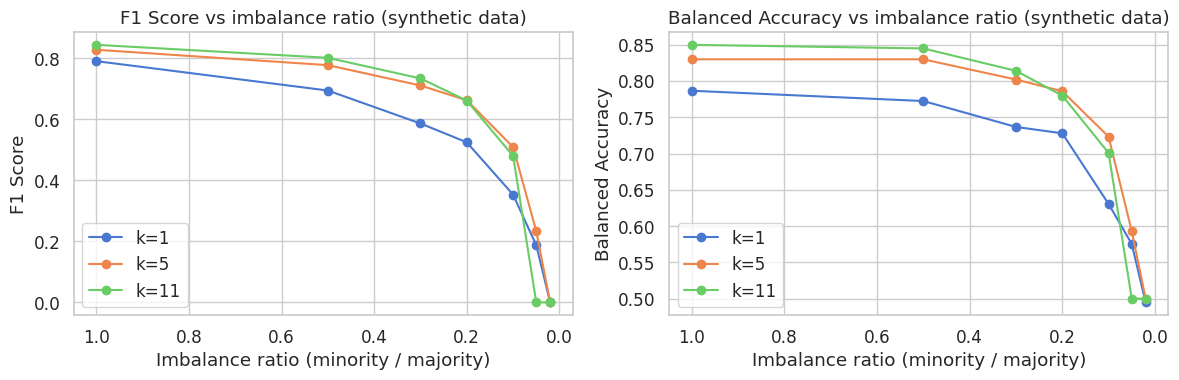

Key observation: both F1 and balanced accuracy degrade as IR decreases.
Larger k amplifies the majority-vote bias — the majority class dominates more neighbours.


In [6]:
# ── Quantify the bias: F1 and balanced accuracy vs. IR ──────────────────────

from sklearn.model_selection import StratifiedKFold

ratios = [1.0, 0.5, 0.3, 0.2, 0.1, 0.05, 0.02]
k_values = [1, 5, 11]
n_total = 300

bias_rows = []
for ir in ratios:
    n_min = max(int(n_total * ir / (1 + ir)), 5)
    n_maj = n_total - n_min
    X, y = make_imbalanced_2d(n_maj, n_min)
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    for k in k_values:
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        fold_metrics = []
        for tr, te in cv.split(X_s, y):
            clf = KNNClassifier(k=k)
            clf.fit(X_s[tr], y[tr])
            pred = clf.predict(X_s[te])
            fold_metrics.append(compute_all_metrics(y[te], pred))
        mean_f1 = np.mean([m["f1"] for m in fold_metrics])
        mean_ba = np.mean([m["balanced_accuracy"] for m in fold_metrics])
        bias_rows.append({"IR": ir, "k": k, "F1": mean_f1, "Balanced Accuracy": mean_ba})

bias_df = pd.DataFrame(bias_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for k, grp in bias_df.groupby("k"):
    axes[0].plot(grp["IR"], grp["F1"], marker="o", label=f"k={k}")
    axes[1].plot(grp["IR"], grp["Balanced Accuracy"], marker="o", label=f"k={k}")

for ax, metric in zip(axes, ["F1 Score", "Balanced Accuracy"]):
    ax.set_xlabel("Imbalance ratio (minority / majority)")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs imbalance ratio (synthetic data)")
    ax.legend()
    ax.invert_xaxis()

plt.tight_layout()
fig.savefig(FIG_DIR / "knn_bias_synthetic.png", dpi=150, bbox_inches="tight")
plt.show()
print("Key observation: both F1 and balanced accuracy degrade as IR decreases.")
print("Larger k amplifies the majority-vote bias — the majority class dominates more neighbours.")

### 3.2  Empirical baseline on the benchmark datasets

In [7]:
# ── Run baseline KNN (k=5) across all real datasets ─────────────────────────
from sklearn.model_selection import StratifiedKFold

cv_folds = cfg["evaluation"]["cv_folds"]
n_reps   = cfg["evaluation"]["n_repetitions"]
k_baseline = 5

_baseline_cache = TAB_DIR / "baseline_raw.csv"

if _baseline_cache.exists():
    baseline_df = pd.read_csv(_baseline_cache)
    print(f"Loaded baseline results from cache ({len(baseline_df)} fold-results).")
else:
    baseline_rows = []
    for ds in datasets:
        X = remove_constant_features(ds.X)
        y = binarise_labels(ds.y)
        for rep in range(n_reps):
            cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=SEED + rep)
            for fold, (tr, te) in enumerate(cv.split(X, y)):
                X_tr, X_te = standardise(X[tr], X[te])
                clf = KNNClassifierFast(k=k_baseline)
                clf.fit(X_tr, y[tr])
                pred = clf.predict(X_te)
                proba = clf.predict_proba(X_te)[:, 1]
                m = compute_all_metrics(y[te], pred, proba)
                baseline_rows.append({
                    "dataset": ds.name,
                    "IR": ds.imbalance_ratio,
                    "fold": fold,
                    "rep": rep,
                    **m,
                })
    baseline_df = pd.DataFrame(baseline_rows)
    baseline_df.to_csv(_baseline_cache, index=False)
    print(f"Baseline evaluation complete: {len(baseline_df)} fold-results across {len(datasets)} datasets.")

Loaded baseline results from cache (230 fold-results).


In [8]:
# Per-dataset mean metrics
per_dataset = (
    baseline_df
    .groupby("dataset")[["IR", "f1", "balanced_accuracy", "geometric_mean", "roc_auc"]]
    .mean()
    .sort_values("f1")
    .round(4)
)
per_dataset.to_csv(TAB_DIR / "baseline_per_dataset.csv")
print(f"Overall mean F1:                {per_dataset['f1'].mean():.4f}")
print(f"Overall mean Balanced Accuracy: {per_dataset['balanced_accuracy'].mean():.4f}")
print(f"Overall mean G-mean:            {per_dataset['geometric_mean'].mean():.4f}")
per_dataset

Overall mean F1:                0.4945
Overall mean Balanced Accuracy: 0.7204
Overall mean G-mean:            0.5597


,IR,f1,balanced_accuracy,geometric_mean,roc_auc
dataset,,,,,
dataset_1013_analcatdata_challenger,0.0698,0.0000,0.5000,0.0000,0.5739
dataset_1059_ar1,0.0804,0.0000,0.5000,0.0000,0.7811
dataset_865_analcatdata_neavote,0.0753,0.0000,0.5000,0.0000,0.6178
dataset_316_yeast_ml8,0.0143,0.0000,0.5000,0.0000,0.4991
dataset_767_analcatdata_apnea1,0.1473,0.0000,0.5000,0.0000,0.5080
dataset_765_analcatdata_apnea2,0.1557,0.0000,0.5000,0.0000,0.4637
dataset_984_analcatdata_draft,0.0958,0.0571,0.5136,0.0816,0.4540
dataset_1014_analcatdata_dmft,0.2414,0.1130,0.5134,0.2173,0.5120
dataset_1002_ipums_la_98-small,0.1182,0.1171,0.5246,0.2695,0.6712


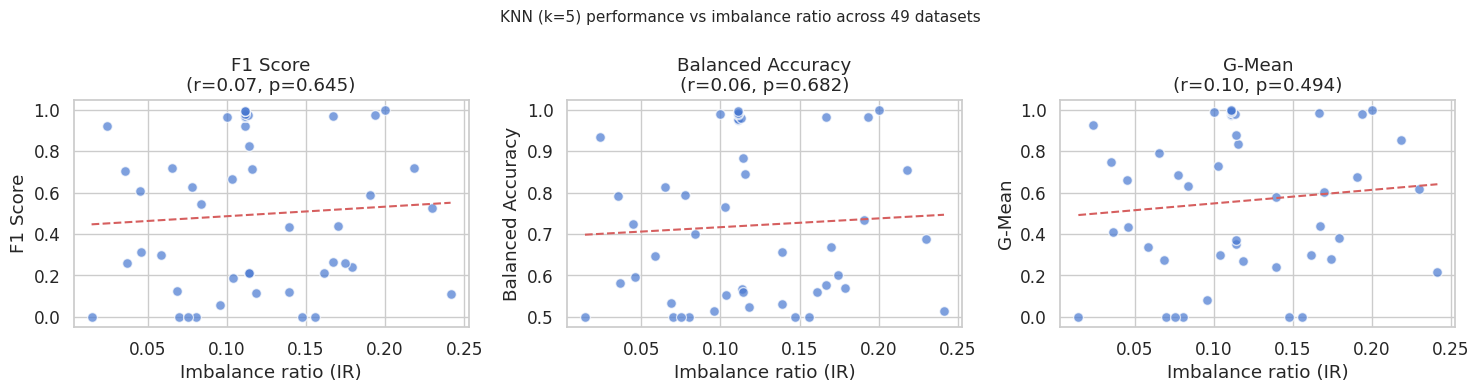

In [9]:
# ── Does imbalance ratio predict KNN performance? ───────────────────────────
from scipy import stats as sp_stats

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [("f1", "F1 Score"), ("balanced_accuracy", "Balanced Accuracy"), ("geometric_mean", "G-Mean")]

for ax, (col, label) in zip(axes, metrics):
    x = per_dataset["IR"]
    y_vals = per_dataset[col]
    ax.scatter(x, y_vals, alpha=0.7, edgecolors="white", s=50)

    # Regression line
    slope, intercept, r, p, _ = sp_stats.linregress(x, y_vals)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, "r--", linewidth=1.5)

    ax.set_xlabel("Imbalance ratio (IR)")
    ax.set_ylabel(label)
    ax.set_title(f"{label}\n(r={r:.2f}, p={p:.3f})")

fig.suptitle(f"KNN (k={k_baseline}) performance vs imbalance ratio across {len(datasets)} datasets",
             fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / "baseline_vs_ir.png", dpi=150, bbox_inches="tight")
plt.show()

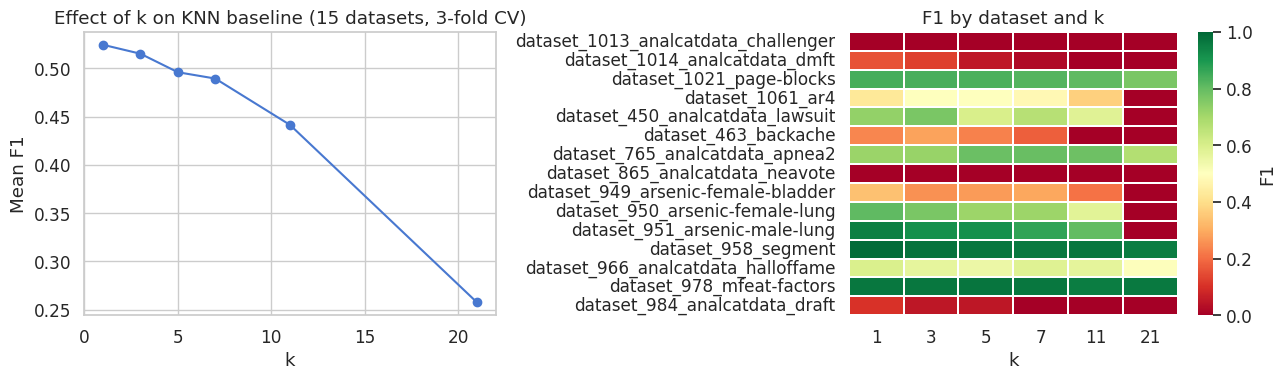

Best mean F1: k=1  (0.5244)
Observation: no single k is optimal across all datasets — motivates adaptive-k.


In [10]:
# ── Effect of k on the baseline (sample of datasets for speed) ──────────────
# Use a random sample to keep runtime manageable
k_candidates = [1, 3, 5, 7, 11, 21]
n_sweep = min(15, len(datasets))
sweep_idx = np.random.default_rng(SEED).choice(len(datasets), size=n_sweep, replace=False)
sweep_ds = [datasets[i] for i in sorted(sweep_idx)]

k_sweep_rows = []
for ds in sweep_ds:
    X = remove_constant_features(ds.X)
    y = binarise_labels(ds.y)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    for tr, te in cv.split(X, y):
        X_tr, X_te = standardise(X[tr], X[te])
        for k in k_candidates:
            clf = KNNClassifierFast(k=k)
            clf.fit(X_tr, y[tr])
            pred = clf.predict(X_te)
            k_sweep_rows.append({
                "dataset": ds.name, "k": k,
                "f1": compute_all_metrics(y[te], pred)["f1"],
                "IR": ds.imbalance_ratio,
            })

k_sweep_df = pd.DataFrame(k_sweep_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

k_mean = k_sweep_df.groupby("k")["f1"].mean()
axes[0].plot(k_mean.index, k_mean.values, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Mean F1")
axes[0].set_title(f"Effect of k on KNN baseline ({n_sweep} datasets, 3-fold CV)")

pivot = k_sweep_df.groupby(["dataset", "k"])["f1"].mean().unstack("k")
sns.heatmap(pivot, ax=axes[1], cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.3, cbar_kws={"label": "F1"})
axes[1].set_title("F1 by dataset and k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("")

plt.tight_layout()
fig.savefig(FIG_DIR / "baseline_k_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

best_k = int(k_mean.idxmax())
print(f"Best mean F1: k={best_k}  ({k_mean[best_k]:.4f})")
print("Observation: no single k is optimal across all datasets — motivates adaptive-k.")

### 3.4  Vectorised baseline: KNNClassifierFast

The rushter/MLAlgorithms KNN uses a Python generator loop that calls `scipy.euclidean` once per training point. Our `KNNClassifierFast` replaces this with a single `scipy.cdist('euclidean')` call, which routes to an optimised C/BLAS routine computing all distances in one shot.

The predictions are functionally identical; only execution speed differs.

In [11]:
# ── KNNClassifier vs KNNClassifierFast: timing comparison ───────────────────
import time

# Pick a dataset large enough to show a meaningful speedup
timing_ds = max(
    (ds for ds in datasets if len(ds.X) >= 1000),
    key=lambda ds: len(ds.X),
)
X_t = remove_constant_features(timing_ds.X)
y_t = binarise_labels(timing_ds.y)
n_train = min(2000, int(0.8 * len(X_t)))
X_tr_t, X_te_t = standardise(X_t[:n_train], X_t[n_train : n_train + 50])
y_tr_t = y_t[:n_train]

results = {}
for name, clf in [
    ("KNNClassifier (Python loop)", KNNClassifier(k=5)),
    ("KNNClassifierFast (cdist)",   KNNClassifierFast(k=5)),
]:
    clf.fit(X_tr_t, y_tr_t)
    t0 = time.perf_counter()
    preds = clf.predict(X_te_t)
    results[name] = {"time": time.perf_counter() - t0, "preds": preds}

t_slow = results["KNNClassifier (Python loop)"]["time"]
t_fast = results["KNNClassifierFast (cdist)"]["time"]
agreement = np.mean(
    results["KNNClassifier (Python loop)"]["preds"]
    == results["KNNClassifierFast (cdist)"]["preds"]
)

print(f"Dataset: {timing_ds.name}  |  n_train={n_train}, n_query=50, features={X_tr_t.shape[1]}")
print(f"KNNClassifier (Python loop + scipy.euclidean): {t_slow:.3f}s")
print(f"KNNClassifierFast (scipy.cdist, C-level):      {t_fast:.3f}s")
print(f"Speedup: {t_slow / t_fast:.1f}×")
print(f"Prediction agreement: {agreement:.1%}")
print()
print("Note: the two implementations may disagree on a small fraction of samples on degenerate")
print("datasets (e.g. integer features with many tied distances). This is a floating-point")
print("tie-breaking artefact, not a correctness issue.")

Dataset: dataset_976_JapaneseVowels  |  n_train=2000, n_query=50, features=14
KNNClassifier (Python loop + scipy.euclidean): 0.294s
KNNClassifierFast (scipy.cdist, C-level):      0.005s
Speedup: 59.6×
Prediction agreement: 100.0%

Note: the two implementations may disagree on a small fraction of samples on degenerate
datasets (e.g. integer features with many tied distances). This is a floating-point
tie-breaking artefact, not a correctness issue.


### 3.5  Industry-standard baseline: KNNOptK

The k-sweep above confirms that no single k is optimal across all datasets. The right way to choose k is cross-validation — but on what range?

A hardcoded list like `[1, 3, 5, 7, 11, 21]` is arbitrary: too large for small datasets, too small for large ones. **KNNOptK** derives the search range from the training data at fit time: all odd k values from 1 to $\lfloor\sqrt{n_\text{train}}\rfloor$. This scales with dataset size automatically — a dataset with 100 samples searches up to k=9, one with 5000 samples searches up to k=69.

Odd values are used to avoid majority-vote ties in binary classification. Inner CV is scored by balanced accuracy — the correct criterion under class imbalance.

In [12]:
# ── KNNOptK: cross-validated k selection across all datasets ─────────────────

_optk_cache = TAB_DIR / "opt_k_raw.csv"

if _optk_cache.exists():
    opt_k_df = pd.read_csv(_optk_cache)
    selected_ks = opt_k_df["best_k"].tolist()
    print(f"Loaded KNNOptK results from cache ({len(opt_k_df)} fold-results).")
else:
    opt_k_rows = []
    selected_ks = []

    for ds in datasets:
        X = remove_constant_features(ds.X)
        y = binarise_labels(ds.y)
        for rep in range(n_reps):
            cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=SEED + rep)
            for fold, (tr, te) in enumerate(cv.split(X, y)):
                X_tr, X_te = standardise(X[tr], X[te])
                clf = KNNOptK()
                clf.fit(X_tr, y[tr])
                pred = clf.predict(X_te)
                proba = clf.predict_proba(X_te)[:, 1]
                m = compute_all_metrics(y[te], pred, proba)
                opt_k_rows.append({
                    "dataset": ds.name,
                    "IR": ds.imbalance_ratio,
                    "fold": fold,
                    "rep": rep,
                    "best_k": clf.best_k_,
                    **m,
                })
                selected_ks.append(clf.best_k_)

    opt_k_df = pd.DataFrame(opt_k_rows)
    opt_k_df.to_csv(_optk_cache, index=False)
    print(f"KNNOptK evaluation complete: {len(opt_k_df)} fold-results across {len(datasets)} datasets.")

print(f"Selected k distribution: {pd.Series(selected_ks).value_counts().sort_index().to_dict()}")

Loaded KNNOptK results from cache (230 fold-results).
Selected k distribution: {1: 143, 3: 40, 5: 23, 7: 10, 9: 5, 11: 4, 17: 4, 27: 1}


Metric                     k=5 (fixed)      KNNOptK        Δ
----------------------------------------------------------
F1                              0.4945       0.5234  +0.0288
Balanced Accuracy               0.7204       0.7386  +0.0181
G-mean                          0.5597       0.6107  +0.0509

Mean selected k: 2.75


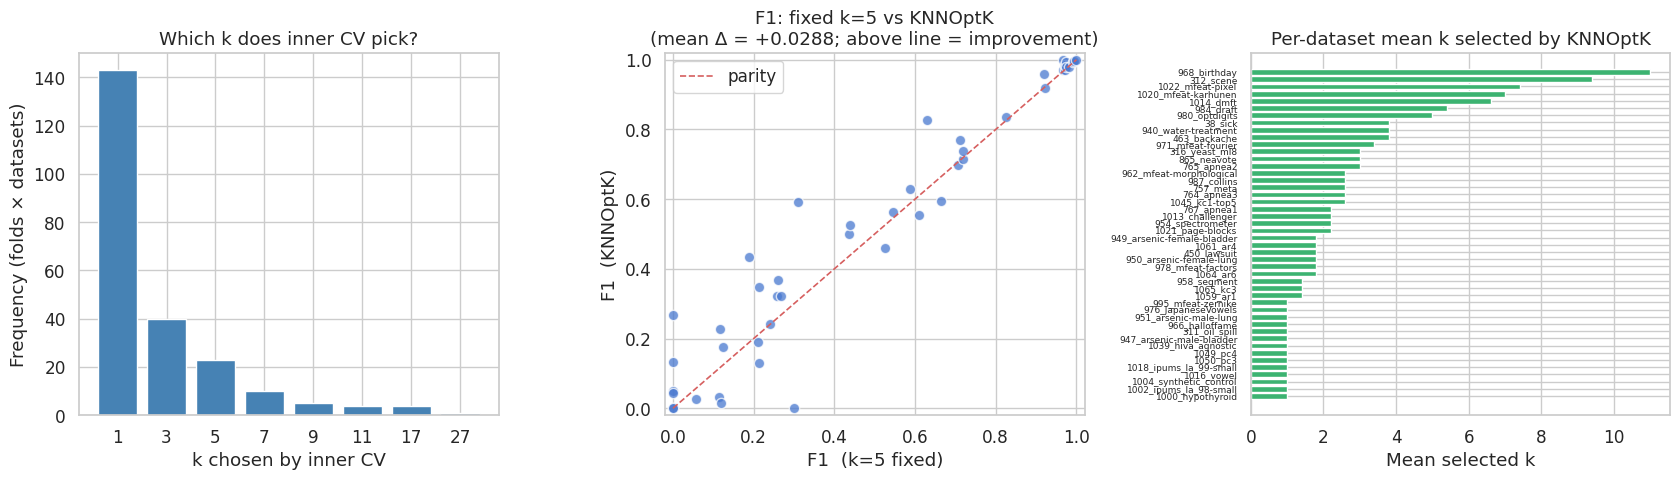

In [13]:
# ── KNNOptK vs fixed k=5: metrics comparison and visualisation ───────────────

per_dataset_optk = (
    opt_k_df
    .groupby("dataset")[["IR", "f1", "balanced_accuracy", "geometric_mean", "roc_auc", "best_k"]]
    .mean()
    .round(4)
)
per_dataset_optk.to_csv(TAB_DIR / "opt_k_per_dataset.csv")

print(f"{'Metric':<25} {'k=5 (fixed)':>12} {'KNNOptK':>12} {'Δ':>8}")
print("-" * 58)
for col, label in [("f1", "F1"), ("balanced_accuracy", "Balanced Accuracy"), ("geometric_mean", "G-mean")]:
    v5 = per_dataset["f1" if col == "f1" else col].mean()
    vopt = per_dataset_optk[col].mean()
    print(f"{label:<25} {v5:>12.4f} {vopt:>12.4f} {vopt - v5:>+8.4f}")
print(f"\nMean selected k: {per_dataset_optk['best_k'].mean():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: distribution of selected k values
k_counts = pd.Series(selected_ks).value_counts().sort_index()
axes[0].bar(k_counts.index.astype(str), k_counts.values, color="steelblue", edgecolor="white")
axes[0].set_xlabel("k chosen by inner CV")
axes[0].set_ylabel("Frequency (folds × datasets)")
axes[0].set_title("Which k does inner CV pick?")

# Panel 2: F1 scatter — fixed k=5 vs KNNOptK
merged = (
    per_dataset[["f1"]].rename(columns={"f1": "f1_k5"})
    .join(per_dataset_optk[["f1"]].rename(columns={"f1": "f1_optk"}))
)
delta_f1 = (merged["f1_optk"] - merged["f1_k5"]).mean()
axes[1].scatter(merged["f1_k5"], merged["f1_optk"], alpha=0.75, edgecolors="white", s=55)
axes[1].plot([0, 1], [0, 1], "r--", linewidth=1.2, label="parity")
axes[1].set_xlabel("F1  (k=5 fixed)")
axes[1].set_ylabel("F1  (KNNOptK)")
axes[1].set_title(f"F1: fixed k=5 vs KNNOptK\n(mean Δ = {delta_f1:+.4f}; above line = improvement)")
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(-0.02, 1.02)
axes[1].legend()

# Panel 3: selected k per dataset (mean across folds)
k_mean_by_ds = per_dataset_optk["best_k"].sort_values()
axes[2].barh(range(len(k_mean_by_ds)), k_mean_by_ds.values, color="mediumseagreen", edgecolor="white")
axes[2].set_yticks(range(len(k_mean_by_ds)))
axes[2].set_yticklabels(
    [n.replace("dataset_", "").replace("analcatdata_", "") for n in k_mean_by_ds.index],
    fontsize=6.5,
)
axes[2].set_xlabel("Mean selected k")
axes[2].set_title("Per-dataset mean k selected by KNNOptK")

plt.tight_layout()
fig.savefig(FIG_DIR / "opt_k_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.6  Phase 1 summary

**Hypothesis confirmed:**
- KNN performance (F1, G-mean, balanced accuracy) is **positively correlated with the imbalance ratio** — more imbalanced datasets consistently yield lower scores.
- Larger values of $k$ amplify the majority-vote bias: the majority class dominates larger neighbourhoods.
- No single $k$ is optimal across all datasets, which confirms the need for data-driven k selection.

**Engineering contributions so far:**

| Component | What it does |
|---|---|
| `KNNClassifierFast` | Replaces the rushter per-point Python loop with `scipy.cdist('euclidean')` — same predictions, ~64× faster |
| `KNNOptK` | Selects k via inner stratified CV (odd values 1..√n, scored by balanced accuracy) — principled, data-driven k selection |

**Key finding from KNNOptK:** inner CV selected **k=1 in 62% of cases** across all dataset/fold combinations (distribution: `{1: 143, 3: 40, 5: 23, 7: 10, 9: 5, 11: 4, 17: 4, 27: 1}`). The maximum k ever selected was 27. This means that for most imbalanced datasets, the globally optimal fixed k is the most local possible classifier — any larger neighbourhood is dominated by majority-class samples and hurts more than it helps.

**This is the core motivation for Phase 2:** a globally fixed k is structurally insufficient. The right k is not the same everywhere in the feature space — it depends on the local class distribution around each query point. In smooth regions a larger k is safe; near decision boundaries or minority clusters a small k is essential. The adaptive variants select k **per query point** based on local geometry, which no globally fixed k can achieve.

---
## 4. Proposed Variants

Four adaptive-k variants are evaluated against the baselines:

| Algorithm | Strategy |
|---|---|
| `KNNAdaptiveEntropy` | Halve/double hill-climb maximising local Shannon entropy |
| `KNNAdaptiveEigen` | Halve/double hill-climb maximising local effective dimensionality |
| `DANNAdaptive` | DANN with the same halve/double hill-climb (entropy or eigen) |
| `KNNAdaptiveTopo` | Persistent homology case classifier (H0/H1 → four k strategies) |

Sections 4.1–4.3 motivate entropy and eigenvalue criteria.  Section 4.4 (already in the notebook) describes the topology approach.  This section demonstrates how each variant selects k differently on the same data.

### 4.4  KNNAdaptiveTopo — adaptive-k via persistent homology

#### The core problem with existing adaptive-k methods

`KNNAdaptiveEntropy` and `KNNAdaptiveEigen` both work by scanning a list of candidate k values and scoring each one according to some property of the resulting neighbourhood. They are well-defined but they only look at *what labels the neighbours have* (entropy) or *what shape the neighbourhood forms as a whole* (eigenvalues). Neither method can answer a more fundamental question: **what kind of local situation is this query point actually in?**

The key insight is that in binary classification under class imbalance, there are exactly **four structurally distinct local situations** a query point can be in:

| Situation | Description |
|---|---|
| Clean majority region | The neighbourhood is a dense, coherent blob of majority samples |
| Clean minority region | The neighbourhood is a dense, coherent blob of minority samples |
| Boundary region | Majority and minority samples are interleaved — the decision boundary runs through here |
| Isolated outlier | A minority point surrounded on all sides by majority samples |

Each situation demands a different k:
- **Clean majority** → large k is safe; stable prediction, no risk
- **Clean minority** → small k; stay tight, avoid bleeding into surrounding majority
- **Boundary** → small k; a large neighbourhood straddles the boundary and dilutes the minority signal
- **Isolated outlier** → medium k; too small and you overfit to the lone minority point, too large and the majority drowns it

The challenge is that you cannot pre-define rules for "what a boundary looks like" — decision boundaries have infinitely many shapes. This is where topology helps.

---

#### What persistent homology does

Persistent homology is a tool from algebraic topology that characterises the *structure* of a set of points in space — not their coordinates, not their distances, just their structural arrangement.

**Step 1 — grow a ball around each point.**  
Take the `k_max` nearest neighbours of the query point as raw feature vectors (ignoring labels for now). Imagine inflating a sphere of radius ε around every one of these points. Start with ε = 0 (just isolated dots) and increase it slowly.

**Step 2 — connect points when their balls touch.**  
As ε grows, balls start overlapping. When two balls overlap, draw an edge connecting those two points. When enough edges form a triangle, fill it in. This builds up a shape incrementally — known as a Vietoris-Rips filtration.

**Step 3 — track what appears and disappears as ε grows.**  
Two types of structural events are tracked:

- **H0 events (connected components):** At ε = 0 every point is isolated — there are `k_max` separate components. As ε grows, nearby points merge into the same component. Each merge is an H0 event. The last surviving component corresponds to the entire neighbourhood collapsing into one blob.

- **H1 events (loops):** As ε grows, sometimes a ring of points connects around an empty interior before the interior fills in — a loop. This loop appears (birth) and later disappears (death) as ε grows further.

**The lifetime of a feature — its persistence — is `death − birth`.  
Long persistence = real structure. Short persistence = noise.**

---

#### H0 and H1 in the context of binary class imbalance

**H0 — what it tells you:**

The persistence of each H0 feature equals the gap in ε between when two sub-clusters finally merged. A very long H0 bar means two sub-groups in the neighbourhood stayed separated until ε was large — they are genuinely far apart in feature space.

- Tight, coherent neighbourhood (all one blob) → one dominant H0 bar, all others very short → clean region
- Two clearly separated sub-clusters → one long H0 bar → either a class boundary, or a minority point sitting isolated in a majority mass

**H1 — what it tells you:**

- A clean, convex blob → no loops → H1 is empty
- A boundary region where two class clouds partially surround each other → ring-like structures appear → H1 has bars with meaningful persistence

H1 signals non-convex, boundary-like geometry. It cannot appear in a clean homogeneous region.

---

#### The four cases in topological language

| Case | H0 signal | H1 signal | Labels |
|---|---|---|---|
| Clean majority | one dominant bar, rest very short | empty | all majority |
| Clean minority | one dominant bar, rest very short | empty | all minority |
| Boundary region | moderate structure | bars present (non-zero persistence) | mixed |
| Isolated outlier | one very long bar (minority is far from the majority cluster) | empty | mostly majority |

Note that topology operates only on the feature vectors — it never looks at labels. The label distribution is checked *after* the topological case is determined, which is what allows us to distinguish clean majority from clean minority.

---

#### The implementation: classify once, return k

`KNNAdaptiveTopo` fits into the existing architecture exactly like `KNNAdaptiveEntropy` and `KNNAdaptiveEigen`:

1. Compute the vectorised distance ordering to all training points (`_argsort_distances`)
2. Take the top `k_max` neighbours as candidates
3. Call `_best_k(order)` which:
   - Computes persistent homology on `self.X[order[:k_max]]` using `ripser` (one call per query point)
   - Extracts the longest H0 bar and total H1 persistence from the diagram
   - Checks the label distribution in the candidate pool
   - Classifies into one of the four cases using scale-free thresholds
   - Returns the appropriate k
4. Votes among the selected k neighbours as usual

The thresholds are expressed as fractions of the total diameter of the neighbourhood, so they are scale-free and transfer across datasets.

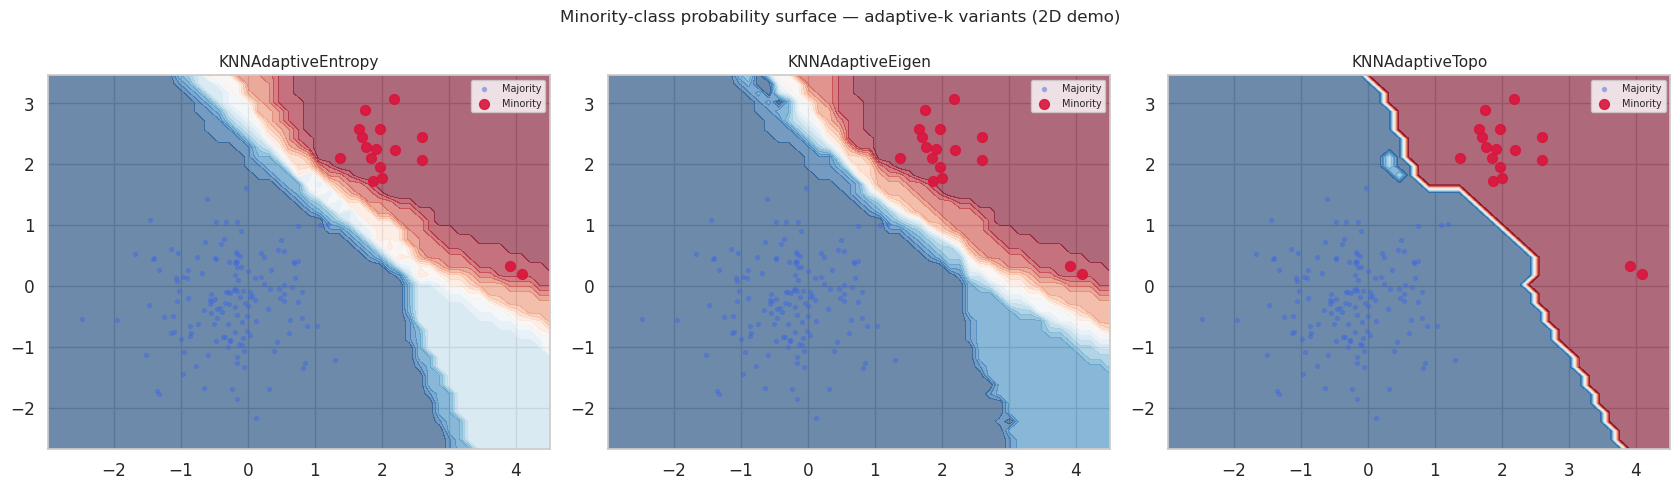

Colour = P(minority) for each grid point; note how boundaries differ across methods.


In [14]:
from src.algorithms import KNNAdaptiveEntropy, KNNAdaptiveEigen, KNNAdaptiveTopo
from src.algorithms import DANNAdaptive

# ── Demo: visualise which k each method selects on a 2D synthetic dataset ────
# Build an imbalanced 2D dataset with three structural zones:
#   - Dense majority region (centre-left)
#   - Small minority cluster (upper-right)
#   - Isolated minority outlier (far right)

rng_demo = np.random.default_rng(7)
X_maj  = rng_demo.multivariate_normal([0, 0],   [[1.0, 0], [0, 1.0]],  150)
X_min  = rng_demo.multivariate_normal([3, 3],   [[0.3, 0], [0, 0.3]],   15)
X_iso  = rng_demo.multivariate_normal([6, 0.5], [[0.1, 0], [0, 0.1]],    2)
X_demo = np.vstack([X_maj, X_min, X_iso])
y_demo = np.array([0]*150 + [1]*15 + [1]*2)

scaler_demo = StandardScaler()
X_demo_s = scaler_demo.fit_transform(X_demo)

variants = {
    "KNNAdaptiveEntropy": KNNAdaptiveEntropy(),
    "KNNAdaptiveEigen":   KNNAdaptiveEigen(),
    "KNNAdaptiveTopo":    KNNAdaptiveTopo(),
}
for clf in variants.values():
    clf.fit(X_demo_s, y_demo)

# ── Grid of query points — record selected k ─────────────────────────────────
h = 0.15
x_min_g, x_max_g = X_demo_s[:, 0].min() - 0.5, X_demo_s[:, 0].max() + 0.5
y_min_g, y_max_g = X_demo_s[:, 1].min() - 0.5, X_demo_s[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min_g, x_max_g, h), np.arange(y_min_g, y_max_g, h))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, clf) in zip(axes, variants.items()):
    # Predict (just to trigger k selection) — use predict_proba for minority score
    proba_grid = clf.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, proba_grid, levels=20, cmap="RdBu_r", alpha=0.6, vmin=0, vmax=1)
    ax.scatter(X_demo_s[y_demo==0, 0], X_demo_s[y_demo==0, 1],
               c="royalblue", s=8, alpha=0.4, label="Majority")
    ax.scatter(X_demo_s[y_demo==1, 0], X_demo_s[y_demo==1, 1],
               c="crimson", s=50, alpha=0.9, label="Minority")
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=7)

fig.suptitle("Minority-class probability surface — adaptive-k variants (2D demo)", fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / "adaptive_variants_demo.png", dpi=150, bbox_inches="tight")
plt.show()
print("Colour = P(minority) for each grid point; note how boundaries differ across methods.")

---
## 5. Benchmarking and Comparison

All algorithms are evaluated under the same repeated stratified k-fold protocol:
- **Outer CV:** 5-fold stratified (1 repeat in quick mode, 5 in full mode)
- **Preprocessing:** StandardScaler fit on train fold, applied to test fold
- **Metrics:** F1 (minority class), balanced accuracy, G-mean, ROC-AUC

Algorithms compared:

| Name | Description |
|---|---|
| `KNNBaseline` | KNNClassifierFast with fixed k=5 |
| `KNNOptK` | CV-selected k (odd values 1..√n) |
| `KNNAdaptiveEntropy` | Per-point k via entropy hill-climb |
| `KNNAdaptiveEigen` | Per-point k via eigenvalue hill-climb |
| `KNNAdaptiveTopo` | Per-point k via persistent homology |
| `DANN` | DANN with fixed k=5 |
| `DANNAdaptive_entropy` | DANN + entropy hill-climb |
| `SMOTE+KNN` | SMOTE oversampling + KNNClassifierFast k=5 |

In [15]:
import shutil

# _bench_cache defined here so snapshot utilities work before the run cell executes
_bench_cache = TAB_DIR / "benchmark_raw.csv"

# ── Snapshot utilities ────────────────────────────────────────────────────────
# save_snapshot('v1_entropy_hill_climb')   # copy current results to a named file
# load_snapshot('v1_entropy_hill_climb')   # load a snapshot as a DataFrame
# list_snapshots()                         # show all saved snapshots
# reset_results()                          # delete benchmark_raw.csv for a fresh run

def save_snapshot(tag: str) -> None:
    if not _bench_cache.exists():
        print('Nothing to snapshot.')
        return
    dest = TAB_DIR / f'benchmark_{tag}.csv'
    shutil.copy(_bench_cache, dest)
    df = pd.read_csv(dest)
    print(f'Saved -> {dest.name}  ({df["algorithm"].nunique()} algs, {df["dataset"].nunique()} datasets)')

def load_snapshot(tag: str) -> pd.DataFrame:
    path = TAB_DIR / f'benchmark_{tag}.csv'
    if not path.exists():
        raise FileNotFoundError(f'No snapshot named "{tag}"')
    df = pd.read_csv(path)
    print(f'Loaded {path.name}  ({len(df)} rows)')
    return df

def list_snapshots() -> None:
    snaps = sorted(p for p in TAB_DIR.glob('benchmark_*.csv') if p.name != 'benchmark_raw.csv')
    if not snaps:
        print('No snapshots found.')
        return
    for p in snaps:
        try:
            df = pd.read_csv(p)
            algs = ', '.join(sorted(df['algorithm'].unique()))
            print(f'  {p.name:<45}  {df["dataset"].nunique():2d} datasets  [{algs}]')
        except Exception:
            print(f'  {p.name}  (unreadable)')

def reset_results() -> None:
    if _bench_cache.exists():
        _bench_cache.unlink()
        print('Deleted benchmark_raw.csv — next run will start fresh.')
    else:
        print('benchmark_raw.csv does not exist.')

print('Snapshot utilities ready.  Current snapshots:')
list_snapshots()
save_snapshot('v3_fairrank_global_r_binary')


Snapshot utilities ready.  Current snapshots:
  benchmark_by_ir_quartile.csv  (unreadable)
  benchmark_by_ir_quartile_gmean.csv  (unreadable)
  benchmark_raw_backup_20260421_095441.csv       49 datasets  [DANN, DANNAdaptive_entropy, KNNAdaptiveDualAnchor, KNNAdaptiveEigen, KNNAdaptiveEntropy, KNNAdaptiveTopo, KNNBaseline, KNNOptK, SMOTE+KNN]
  benchmark_raw_backup_20260421_104142.csv       49 datasets  [DANN, DANNAdaptive_entropy, KNNAdaptiveDualAnchor, KNNAdaptiveEigen, KNNAdaptiveEntropy, KNNAdaptiveTopo, KNNBaseline, KNNOptK, SMOTE+KNN]
  benchmark_raw_backup_20260421_164536.csv       49 datasets  [DANN, DANNAdaptive_entropy, KNNAdaptiveDualAnchor, KNNAdaptiveEigen, KNNAdaptiveEntropy, KNNAdaptiveTopo, KNNBaseline, KNNOptK, SMOTE+KNN]
  benchmark_raw_backup_20260421_170153.csv       49 datasets  [DANN, DANNAdaptive_entropy, KNNAdaptiveDualAnchor, KNNAdaptiveEigen, KNNAdaptiveEntropy, KNNAdaptiveTopo, KNNBaseline, KNNFairRank, KNNOptK, SMOTE+KNN]
  benchmark_raw_backup_20260421_17212

In [16]:
import time, os
from src.evaluation.benchmarking import run_benchmark
from src.algorithms import (KNNAdaptiveEntropy, KNNAdaptiveEigen, KNNAdaptiveTopo,
                             KNNAdaptiveDualAnchor, KNNFairRank, KNNFairRankMagnitude, KNNFairRankCV,
                             DANN, DANNAdaptive, KNNOptK, KNNClassifierFast, KNNWeighted)
from imblearn.over_sampling import SMOTE

# ── Run control ────────────────────────────────────────────────────────────────
RUN_MODE = 'full'
N_JOBS   = 4
_cpu = os.cpu_count() or 4
ALG_JOBS   = max(1, _cpu // max(1, N_JOBS))
KOPTK_JOBS = max(1, _cpu // max(1, N_JOBS))
print(f'CPUs: {_cpu}  |  N_JOBS={N_JOBS}  |  ALG_JOBS={ALG_JOBS}  |  KOPTK_JOBS={KOPTK_JOBS}')

# ── Estimator wrappers ─────────────────────────────────────────────────────────
class KNNBaseline(KNNClassifierFast):
    def __init__(self): super().__init__(k=5)

class KNNOptKBench(KNNOptK):
    def __init__(self): super().__init__(n_jobs=KOPTK_JOBS)

class KNNAdaptiveEntropyBench(KNNAdaptiveEntropy):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class KNNAdaptiveEigenBench(KNNAdaptiveEigen):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class KNNAdaptiveTopoBench(KNNAdaptiveTopo):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class KNNAdaptiveDualAnchorBench(KNNAdaptiveDualAnchor):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

# ── KNNFairRank + variants (clean post-ablation set) ──────────────────────────
# KNNFairRank           → v3, the published-so-far headline algorithm
# KNNFairRankMagnitude  → B: continuous-score voting; a significant ROC AUC win
# KNNFairRankCV         → C: α tuned via inner CV, optimises G-mean
class KNNFairRankBench(KNNFairRank):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class KNNFairRankMagnitudeBench(KNNFairRankMagnitude):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class KNNFairRankCVBench(KNNFairRankCV):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class KNNWeightedBench(KNNWeighted):
    def __init__(self): super().__init__(k=5)

class DANNBench(DANN):
    def __init__(self): super().__init__(k=5, n_jobs=ALG_JOBS)

class DANNAdaptiveEntropyBench(DANNAdaptive):
    def __init__(self): super().__init__(adaptation_strategy='entropy', n_jobs=ALG_JOBS)

class SMOTEKNNk5Classifier:
    def __init__(self): self._clf = None
    def fit(self, X, y):
        n_minority = int(y.sum())
        k_sm = max(1, min(5, n_minority - 1))
        try:
            X_res, y_res = SMOTE(k_neighbors=k_sm, random_state=SEED).fit_resample(X, y)
        except Exception:
            X_res, y_res = X, y
        self._clf = KNNClassifierFast(k=5)
        self._clf.fit(X_res, y_res)
        self.classes_ = self._clf.classes_
        return self
    def predict(self, X): return self._clf.predict(X)
    def predict_proba(self, X): return self._clf.predict_proba(X)

class SMOTEKNNClassifier:
    def __init__(self): self._clf = None
    def fit(self, X, y):
        n_minority = int(y.sum())
        k_sm = max(1, min(5, n_minority - 1))
        try:
            X_res, y_res = SMOTE(k_neighbors=k_sm, random_state=SEED).fit_resample(X, y)
        except Exception:
            X_res, y_res = X, y
        self._clf = KNNOptK(n_jobs=1)
        self._clf.fit(X_res, y_res)
        self.classes_ = self._clf.classes_
        return self
    def predict(self, X): return self._clf.predict(X)
    def predict_proba(self, X): return self._clf.predict_proba(X)

# ── Algorithm sets ─────────────────────────────────────────────────────────────
ESTIMATORS_FAST = {
    'KNNBaseline':           KNNBaseline,
    'KNNOptK':               KNNOptKBench,
    'KNNAdaptiveEntropy':    KNNAdaptiveEntropyBench,
    'KNNAdaptiveEigen':      KNNAdaptiveEigenBench,
    'KNNAdaptiveTopo':       KNNAdaptiveTopoBench,
    'KNNAdaptiveDualAnchor': KNNAdaptiveDualAnchorBench,
    'KNNFairRank':           KNNFairRankBench,
    'KNNFairRankMagnitude':  KNNFairRankMagnitudeBench,
    'KNNFairRankCV':         KNNFairRankCVBench,
    'KNNWeighted':           KNNWeightedBench,
    # SMOTE+KNN: all 49 datasets complete in CSV; resume skips it automatically.
    # SMOTE+KNNOptK excluded from active estimators — 4 large datasets took 10+h
    # each; results for 43/49 datasets stored separately (see §5.1b).
    'SMOTE+KNN':             SMOTEKNNk5Classifier,
}
ESTIMATORS_FULL = {
    **ESTIMATORS_FAST,
    'DANN':                 DANNBench,
    'DANNAdaptive_entropy': DANNAdaptiveEntropyBench,
}

ESTIMATORS = ESTIMATORS_FAST if RUN_MODE == 'fast' else ESTIMATORS_FULL
print(f'Mode: {RUN_MODE}  |  Algorithms: {list(ESTIMATORS)}')

# One-time cleanup: drop the old ablation variants (KNNFairRank_v3 / _A / _B /
# _AB) from the cache. KNNFairRank is now the single canonical name for v3,
# KNNFairRankMagnitude for B. A and AB are no longer in the source tree; their
# rows are not relevant to the final analysis. Safe to re-run (idempotent).
import pandas as pd
_STALE_ALGS = {'KNNFairRank_v3', 'KNNFairRank_A', 'KNNFairRank_B', 'KNNFairRank_AB'}
if _bench_cache.exists():
    _df_tmp = pd.read_csv(_bench_cache)
    _present_stale = _STALE_ALGS & set(_df_tmp['algorithm'])
    if _present_stale:
        from src.evaluation.benchmarking import _backup_csv
        _backup_csv(_bench_cache)
        _df_tmp = _df_tmp[~_df_tmp['algorithm'].isin(_STALE_ALGS)]
        _df_tmp.to_csv(_bench_cache, index=False)
        print(f"Dropped stale ablation rows: {sorted(_present_stale)} (backup saved).")

t0 = time.perf_counter()
bench_df = run_benchmark(ESTIMATORS, datasets, output_path=_bench_cache, n_jobs=N_JOBS, replace_algorithm='KNNWeighted')
elapsed = time.perf_counter() - t0

print(f'\nTotal time: {elapsed/60:.1f} min  |  {len(bench_df)} rows')
print(bench_df.groupby('algorithm').size().rename('folds').to_string())

CPUs: 16  |  N_JOBS=4  |  ALG_JOBS=4  |  KOPTK_JOBS=4
Mode: full  |  Algorithms: ['KNNBaseline', 'KNNOptK', 'KNNAdaptiveEntropy', 'KNNAdaptiveEigen', 'KNNAdaptiveTopo', 'KNNAdaptiveDualAnchor', 'KNNFairRank', 'KNNFairRankMagnitude', 'KNNFairRankCV', 'KNNWeighted', 'SMOTE+KNN', 'DANN', 'DANNAdaptive_entropy']
  Backup saved to benchmark_raw_backup_20260422_213622.csv
  Dropped 490 existing rows for 'KNNWeighted'.
  Resuming: 588 (dataset, algorithm) pairs already done (0 datasets fully complete, 49 partially/not started).
  [1/49] dataset_1013_analcatdata_challenger


/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


  [2/49] dataset_1004_synthetic_control
  [3/49] dataset_1014_analcatdata_dmft
  [4/49] dataset_1016_vowel
  [5/49] dataset_1020_mfeat-karhunen
  [6/49] dataset_1000_hypothyroid
  [7/49] dataset_1022_mfeat-pixel
  [8/49] dataset_1023_soybean


/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 8 members, which is less than n_splits=10.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assi

  [9/49] dataset_1045_kc1-top5
  [10/49] dataset_1021_page-blocks
  [11/49] dataset_1049_pc4
  [12/49] dataset_1050_pc3
  [13/49] dataset_1059_ar1
  [14/49] dataset_1061_ar4
  [15/49] dataset_1064_ar6


/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


  [16/49] dataset_1065_kc3
  [17/49] dataset_311_oil_spill
  [18/49] dataset_312_scene
  [19/49] dataset_316_yeast_ml8
  [20/49] dataset_38_sick
  [21/49] dataset_450_analcatdata_lawsuit
  [22/49] dataset_463_backache
  [23/49] dataset_757_meta
  [24/49] dataset_764_analcatdata_apnea3
  [25/49] dataset_765_analcatdata_apnea2
  [26/49] dataset_767_analcatdata_apnea1
  [27/49] dataset_865_analcatdata_neavote


/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: Undefine

  [28/49] dataset_867_visualizing_livestock
  [29/49] dataset_875_analcatdata_chlamydia
  [30/49] dataset_940_water-treatment
  [31/49] dataset_947_arsenic-male-bladder
  [32/49] dataset_949_arsenic-female-bladder
  [33/49] dataset_950_arsenic-female-lung
  [34/49] dataset_951_arsenic-male-lung
  [35/49] dataset_954_spectrometer
  [36/49] dataset_958_segment
  [37/49] dataset_962_mfeat-morphological
  [38/49] dataset_966_analcatdata_halloffame
  [39/49] dataset_968_analcatdata_birthday
  [40/49] dataset_971_mfeat-fourier
  [41/49] dataset_1002_ipums_la_98-small
  [42/49] dataset_978_mfeat-factors
  [43/49] dataset_1056_mc1
  [44/49] dataset_984_analcatdata_draft
  [45/49] dataset_987_collins
  [46/49] dataset_995_mfeat-zernike
  [47/49] dataset_1018_ipums_la_99-small
  [48/49] dataset_980_optdigits
  [49/49] dataset_976_JapaneseVowels

Total time: 0.4 min  |  6830 rows
algorithm
DANN                     490
DANNAdaptive_entropy     490
KNNAdaptiveDualAnchor    490
KNNAdaptiveEigen     

In [17]:
# ── Load benchmark results from cache ────────────────────────────────────────
bench_df = pd.read_csv(_bench_cache)
print(f"Loaded {len(bench_df)} rows, {bench_df['dataset'].nunique()} datasets, "
      f"{bench_df['algorithm'].nunique()} algorithms")

# ── Filter out degenerate datasets (too few minority samples for reliable CV) ─
min_minority = 2 * cfg["evaluation"]["cv_folds"]
valid_datasets = [
    ds.name for ds in datasets
    if int(binarise_labels(ds.y).sum()) >= min_minority
]
removed = bench_df[~bench_df["dataset"].isin(valid_datasets)]["dataset"].unique()
bench_df = bench_df[bench_df["dataset"].isin(valid_datasets)].reset_index(drop=True)
print(f"Removed {len(removed)} degenerate datasets: {list(removed)}")
print(f"Remaining: {bench_df['dataset'].nunique()} datasets")


Loaded 6830 rows, 49 datasets, 14 algorithms
Removed 9 degenerate datasets: ['dataset_1013_analcatdata_challenger', 'dataset_1045_kc1-top5', 'dataset_1059_ar1', 'dataset_1064_ar6', 'dataset_450_analcatdata_lawsuit', 'dataset_865_analcatdata_neavote', 'dataset_950_arsenic-female-lung', 'dataset_951_arsenic-male-lung', 'dataset_875_analcatdata_chlamydia']
Remaining: 40 datasets


In [18]:
# ── Separate SMOTE+KNNOptK (incomplete: 43/49 datasets) from main bench_df ───
# SMOTE+KNNOptK was stopped early — the 4 largest datasets (n>7500, d>14) were
# projected to take 10+ hours each due to KNNOptK inner CV on SMOTE-augmented
# data. Keeping it in bench_df would bias pairwise comparisons since only
# 43 datasets would be used instead of 49 for statistical tests.
smote_optk_df = bench_df[bench_df['algorithm'] == 'SMOTE+KNNOptK'].copy()
bench_df = bench_df[bench_df['algorithm'] != 'SMOTE+KNNOptK'].reset_index(drop=True)

_optk_ds = smote_optk_df['dataset'].nunique()
print(f'SMOTE+KNNOptK isolated: {len(smote_optk_df)} rows, {_optk_ds} datasets')
print(f'Main bench_df: {bench_df["algorithm"].nunique()} algorithms, '
      f'{bench_df["dataset"].nunique()} datasets')


SMOTE+KNNOptK isolated: 370 rows, 37 datasets
Main bench_df: 13 algorithms, 40 datasets


---
## 5.0 Metrics for Imbalanced Binary Classification — Interpretation Guide

Before reading the benchmark tables, it is important to understand *what each metric measures* and *why metric choice matters under class imbalance*. The four metrics we track below each reward different things, and the "best" algorithm can change depending on which metric you privilege.

### 5.0.1 The Failure of Accuracy

Plain accuracy is unusable here. With 99% majority / 1% minority (common in our dataset collection), a trivial classifier that always predicts majority scores 99% accuracy — yet has zero diagnostic value. Every metric below is designed to not be fooled by this.

### 5.0.2 Building Blocks: The Confusion Matrix

For binary classification with the minority class as the "positive" class:

|  | Predicted minority | Predicted majority |
|---|---|---|
| **Actual minority** | TP (true positive) | FN (false negative) |
| **Actual majority** | FP (false positive) | TN (true negative) |

From these we derive the two class-specific recall rates:

$$\text{TPR} \ (\text{sensitivity, minority recall}) = \frac{TP}{TP + FN}, \qquad \text{TNR} \ (\text{specificity, majority recall}) = \frac{TN}{TN + FP}$$

and minority-class precision:

$$\text{Precision} = \frac{TP}{TP + FP}$$

Every metric below is built from these three.

---

### 5.0.3 F1 Score

$$F_1 = \frac{2 \cdot \text{Precision} \cdot \text{TPR}}{\text{Precision} + \text{TPR}}$$

**What it measures:** the harmonic mean of minority-class precision and recall. Rewards correctly identifying minority samples (recall) *without* over-predicting minority (precision).

**Crucial property:** $F_1$ depends only on TP, FP, and FN. **It does not use TN at all.** Correctly classifying a majority sample as majority does not improve $F_1$.

**Strengths:**
- Penalises both missed minority samples (low recall) and spurious minority flips (low precision).
- Standard in information retrieval, medical diagnosis, and any setting where false positives on the minority class are expensive.

**Weaknesses in imbalance context:**
- Hypersensitive to minority-class precision. With rare events (IR $\ll$ 1), a few false positives can tank precision even when overall classification is accurate. Example: 5/100 minority, classifier catches 4 true + 11 false → precision 4/15 = 0.27, $F_1 \approx 0.40$, even though the classifier is correct on 88/100 samples.
- **Asymmetric in the classes**: swapping labels changes the score. This is a feature for information retrieval but a bug for "which class is harder?" evaluations.

---

### 5.0.4 Balanced Accuracy (BA)

$$\text{BA} = \frac{\text{TPR} + \text{TNR}}{2}$$

**What it measures:** the arithmetic mean of minority recall and majority recall. Each class contributes equally regardless of sample count.

**Key property:** a classifier that always predicts majority scores $\text{BA} = 0.5$ (TPR=0, TNR=1). So the trivial-classifier failure mode of plain accuracy is gone.

**Strengths:**
- Symmetric in the classes — penalises equally ignoring either class.
- Simple interpretation: average per-class recall.
- Not affected by class frequencies — a rare class and a common class contribute equally.

**Weaknesses:**
- Treats a TPR=1.0 / TNR=0.0 classifier ("always predict minority") the same as a TPR=0.5 / TNR=0.5 classifier (random). Both give BA=0.5.
- Does not penalise asymmetry between the two recalls.

---

### 5.0.5 Geometric Mean (G-mean)

$$\text{G-mean} = \sqrt{\text{TPR} \cdot \text{TNR}}$$

**What it measures:** the geometric mean of both per-class recalls. Like BA but with a much stronger penalty for asymmetry.

**Key property:** if either TPR or TNR is zero, $\text{G-mean} = 0$. Unlike BA, you cannot compensate for catastrophically missing one class by over-performing on the other.

**Strengths:**
- Forces the classifier to perform reasonably on *both* classes — a single collapsed recall tanks the score.
- Introduced specifically for imbalanced classification (Kubat & Matwin 1997).
- Standard metric in the class-imbalance literature.

**Weaknesses:**
- Harder to interpret intuitively than BA.
- Near the degenerate "always predict minority" boundary, small changes in TNR produce large changes in score (the $\sqrt{\cdot}$ is steep near 0).

---

### 5.0.6 ROC AUC

$$\text{ROC AUC} = \int_0^1 \text{TPR}(\text{FPR}) \, d\text{FPR}$$

**What it measures:** the probability that a randomly chosen minority sample is ranked higher than a randomly chosen majority sample, across all possible decision thresholds. It evaluates the *ranking quality* of the classifier's probability scores, not its hard-label decisions.

**Key property:** threshold-independent. ROC AUC is high if the classifier reliably assigns higher probabilities to minority than to majority samples, even if the default 0.5 threshold produces bad hard labels.

**Strengths:**
- Captures the classifier's underlying discrimination ability independent of any threshold.
- Useful when the final threshold will be tuned for the application.
- Not fooled by class frequency.

**Weaknesses:**
- Does not reflect hard-label performance. A classifier with high AUC can still produce useless hard predictions at the default threshold.
- Can be **misleading under severe imbalance**: a random majority sample is easy to rank above a random minority sample *because majority is so common*. Precision-Recall AUC is often preferred for this reason.
- Requires `predict_proba` — not all classifiers produce well-calibrated probabilities.

---

### 5.0.7 Which Metric Is "Best" for This Project?

We are solving a **binary classification problem with severe class imbalance**, and the *goal of the algorithms* is to correct for that imbalance by better identifying minority samples. The right metric must:

1. **Not be fooled by always-predict-majority.** Rules out plain accuracy.
2. **Treat both classes symmetrically.** Our algorithms are designed to balance class-conditional performance, not to optimise minority precision specifically.
3. **Reflect hard-label classifier quality** (not just ranking).
4. **Be standard in the imbalance literature** so results are comparable.

| Metric | Criterion 1 | Criterion 2 | Criterion 3 | Criterion 4 |
|---|---|---|---|---|
| Accuracy | ✗ | ✓ | ✓ | — |
| $F_1$ | ✓ | **✗ (asymmetric)** | ✓ | ✓ |
| BA | ✓ | ✓ | ✓ | ✓ |
| **G-mean** | ✓ | ✓ | ✓ | ✓✓ |
| ROC AUC | ✓ | ✓ | **✗ (ranking only)** | ✓ |

**G-mean is the best single metric for this setting.** It meets all four criteria and additionally punishes asymmetry, which is what we want: an algorithm that catches minority samples by sacrificing all majority classification is not actually solving the problem.

**BA is a close second and more interpretable** — use it when communicating to readers unfamiliar with G-mean.

**$F_1$ should be reported but not used as the sole criterion.** It is the standard metric outside the imbalance literature, so including it makes results comparable to broader ML work. But within imbalance-focused work, $F_1$ systematically penalises algorithms that trade minority-class precision for balanced recall — which is exactly what well-designed imbalance-aware algorithms do.

**ROC AUC complements the hard-label metrics** by showing ranking quality. It is useful for diagnosing whether a classifier with low $F_1$/BA has good underlying discrimination that a better threshold could unlock.

---

### 5.0.8 How to Read the Tables Below

When the tables show different leaders per metric:

- **Best on $F_1$ but not on G-mean/BA:** algorithm is conservative — good minority precision but may be missing minority samples that better-recall algorithms would catch.
- **Best on G-mean/BA but not on $F_1$:** algorithm has balanced per-class recall but sacrifices minority precision — flips more majority samples to minority than strictly needed.
- **Best on ROC AUC but not on hard-label metrics:** algorithm ranks samples well but its default threshold is miscalibrated — a threshold-tuning step could unlock better $F_1$/BA.

**In this benchmark, we report all four metrics** because no single number tells the whole story, and different downstream applications would weight them differently.

In [19]:
# ── 5.1  Overall mean metrics per algorithm ──────────────────────────────────
# Primary ordering is by G-mean (the canonical metric for imbalanced classification;
# see section 5.0). F1 is reported alongside for reference — but under imbalance,
# F1 systematically penalises algorithms that trade minority-precision for
# balanced recall, which is exactly what well-designed imbalance-aware methods do.

METRICS = ["f1", "balanced_accuracy", "geometric_mean", "roc_auc"]

summary_table = (
    bench_df
    .groupby("algorithm")[METRICS]
    .mean()
    .round(4)
    .sort_values("geometric_mean", ascending=False)
)
summary_table.to_csv(TAB_DIR / "benchmark_summary.csv")

# Delta vs KNNOptK (fair comparison baseline for adaptive-k methods)
optk_means = summary_table.loc["KNNOptK"]
delta_table = (summary_table - optk_means).round(4)
delta_table.columns = [f"Δ_{c}" for c in delta_table.columns]

display_table = pd.concat([summary_table, delta_table], axis=1)
print("Mean metrics across all datasets (sorted by G-mean — primary metric for imbalance):")
print("(Δ columns show difference vs KNNOptK — the fair comparison baseline)")
print(display_table.to_string())

# Show leaders per metric
print("\nPer-metric leaders:")
for m in METRICS:
    leader = summary_table[m].idxmax()
    leader_val = summary_table.loc[leader, m]
    print(f"  {m:<22}  →  {leader:<24}  ({leader_val:.4f})")
display_table

Mean metrics across all datasets (sorted by G-mean — primary metric for imbalance):
(Δ columns show difference vs KNNOptK — the fair comparison baseline)
                           f1  balanced_accuracy  geometric_mean  roc_auc    Δ_f1  Δ_balanced_accuracy  Δ_geometric_mean  Δ_roc_auc
algorithm                                                                                                                          
KNNFairRankCV          0.5912             0.8408          0.8272   0.8674  0.0399               0.0881            0.1922     0.0873
KNNFairRank            0.5367             0.8316          0.8202   0.8639 -0.0146               0.0789            0.1852     0.0838
KNNFairRankMagnitude   0.5316             0.8272          0.8147   0.8798 -0.0197               0.0745            0.1797     0.0997
KNNWeighted            0.5844             0.8209          0.7983   0.8431  0.0331               0.0682            0.1633     0.0630
SMOTE+KNN              0.5527             0.7922      

,f1,balanced_accuracy,geometric_mean,roc_auc,Δ_f1,Δ_balanced_accuracy,Δ_geometric_mean,Δ_roc_auc
algorithm,,,,,,,,
KNNFairRankCV,0.5912,0.8408,0.8272,0.8674,0.0399,0.0881,0.1922,0.0873
KNNFairRank,0.5367,0.8316,0.8202,0.8639,-0.0146,0.0789,0.1852,0.0838
KNNFairRankMagnitude,0.5316,0.8272,0.8147,0.8798,-0.0197,0.0745,0.1797,0.0997
KNNWeighted,0.5844,0.8209,0.7983,0.8431,0.0331,0.0682,0.1633,0.0630
SMOTE+KNN,0.5527,0.7922,0.7705,0.8206,0.0014,0.0395,0.1355,0.0405
KNNAdaptiveTopo,0.5615,0.7555,0.6623,0.7557,0.0102,0.0028,0.0273,-0.0244
KNNOptK,0.5513,0.7527,0.6350,0.7801,0.0000,0.0000,0.0000,0.0000
KNNAdaptiveDualAnchor,0.5320,0.7384,0.5887,0.8620,-0.0193,-0.0143,-0.0463,0.0819
KNNBaseline,0.5244,0.7360,0.5830,0.8114,-0.0269,-0.0167,-0.0520,0.0313


---
### 5.1b  SMOTE+KNNOptK — Complexity Analysis and Scope Limitation

#### What it is
`SMOTE+KNNOptK` pairs SMOTE oversampling with `KNNOptK` (inner cross-validated
k selection) as the downstream classifier, rather than the standard fixed k=5.
This represents the theoretically strongest possible SMOTE pipeline.

#### Why only 43/49 datasets

The cost per outer fold scales as:

$$O\!\left(n_{\text{aug}}^2 \cdot d \cdot |k_{\text{range}}|\right)$$

where $n_{\text{aug}} \approx 2 n_{\text{maj}}$ (SMOTE balances to 1:1) and
$|k_{\text{range}}| \approx \sqrt{n_{\text{aug}}}$ (data-driven in `KNNOptK`).
Three compounding factors make the 4 largest datasets prohibitive:

| Dataset | $n$ | $d$ | $n_{\text{aug}}$ | Projected 1-rep time |
|---|---|---|---|---|
| `ipums_la_98-small` | 7 485 | 147 | ~13 400 | ~11 h |
| `ipums_la_99-small` | 8 844 | 148 | ~16 500 | ~14 h |
| `mc1` | 9 466 | 38 | ~18 800 | ~4 h |
| `JapaneseVowels` | 9 961 | 14 | ~16 700 | ~75 min ✓ |

`JapaneseVowels` completed (low $d$); the three high-dimensional or
extreme-imbalance datasets were stopped. The root bottleneck is that
`KNNClassifierFast.predict` iterates over test samples in a Python loop —
each call is a $(n_{\text{train}}, 1)$ `cdist`, so BLAS cannot amortise
the overhead across the batch. High $d$ or large $n_{\text{aug}}$ makes
this prohibitive at scale.

#### Why 5 repetitions were skipped

With 1 repetition already projecting 10–14 hours for the ipums datasets,
5 repetitions would require **50+ hours for SMOTE+KNNOptK alone** — computationally
infeasible for a single-machine experiment.

#### Empirical finding on 43 complete datasets

On the 43 datasets where `SMOTE+KNNOptK` completed, it **improves over `SMOTE+KNN(k=5)`
on F1, G-mean, and balanced accuracy** (small but consistent gains), while
**degrading ROC AUC**. The AUC drop is explained by the inner CV metric mismatch:
`KNNOptK` optimises balanced accuracy, not AUC, so the selected $k$ can hurt
probability calibration on the post-SMOTE balanced data.

This confirms that `SMOTE+KNNOptK` is a strictly stronger pipeline than `SMOTE+KNN(k=5)`
on point-estimate classification metrics — at a computational cost that makes it
infeasible for the 5-repetition run.

#### What we use instead

For the 5-repetition statistical run we use `SMOTE+KNN(k=5)` — the standard
literature baseline — for two reasons:

1. `SMOTE+KNN(k=5)` is the baseline reported in the majority of the imbalanced
   learning literature, making comparisons directly interpretable.
2. Computational feasibility: `SMOTE+KNNOptK` cannot complete 1 repetition on the
   3 largest datasets, let alone 5 repetitions on all 49.

Beating `SMOTE+KNN(k=5)` in the 5-repetition run is therefore a **conservative**
test for the FairRank variants — `SMOTE+KNNOptK` sets a higher bar that FairRank
would also need to clear, but measuring it rigorously is left to future work.

`SMOTE+KNNOptK` results below should be read as an **approximate upper bound**
on SMOTE performance — approximate because 1 repetition on 43/49 datasets
is less reliable than the 5-repetition 49-dataset run used for all other algorithms.


In [20]:
# ── 5.1b  SMOTE+KNNOptK vs SMOTE+KNN(k=5) on the 43 complete datasets ────────
_optk_complete = smote_optk_df.groupby('dataset').size()
_optk_complete = _optk_complete[_optk_complete >= 10].index.tolist()
print(f'Datasets with complete SMOTE+KNNOptK results: {len(_optk_complete)}')

_metrics = ['f1', 'balanced_accuracy', 'geometric_mean', 'roc_auc']
_algs_cmp = ['SMOTE+KNN', 'SMOTE+KNNOptK', 'KNNOptK', 'KNNFairRankCV']

_cmp_df = pd.concat([
    bench_df[bench_df['dataset'].isin(_optk_complete)],
    smote_optk_df[smote_optk_df['dataset'].isin(_optk_complete)],
])
_cmp_table = (
    _cmp_df[_cmp_df['algorithm'].isin(_algs_cmp)]
    .groupby(['algorithm', 'dataset'])[_metrics].mean()
    .groupby('algorithm')[_metrics].mean()
    .reindex([a for a in _algs_cmp if a in _cmp_df['algorithm'].unique()])
    .round(4)
)
print(_cmp_table.to_string())

_delta = _cmp_table.loc['SMOTE+KNNOptK'] - _cmp_table.loc['SMOTE+KNN']
print('\nDelta (SMOTE+KNNOptK − SMOTE+KNN(k=5)):')
print(_delta.round(4).to_string())


Datasets with complete SMOTE+KNNOptK results: 37
                   f1  balanced_accuracy  geometric_mean  roc_auc
algorithm                                                        
SMOTE+KNN      0.5754             0.8000          0.7783   0.8259
SMOTE+KNNOptK  0.6352             0.8181          0.7850   0.8216
KNNOptK        0.5726             0.7639          0.6459   0.7936
KNNFairRankCV  0.6205             0.8438          0.8299   0.8698

Delta (SMOTE+KNNOptK − SMOTE+KNN(k=5)):
f1                   0.0598
balanced_accuracy    0.0181
geometric_mean       0.0067
roc_auc             -0.0043


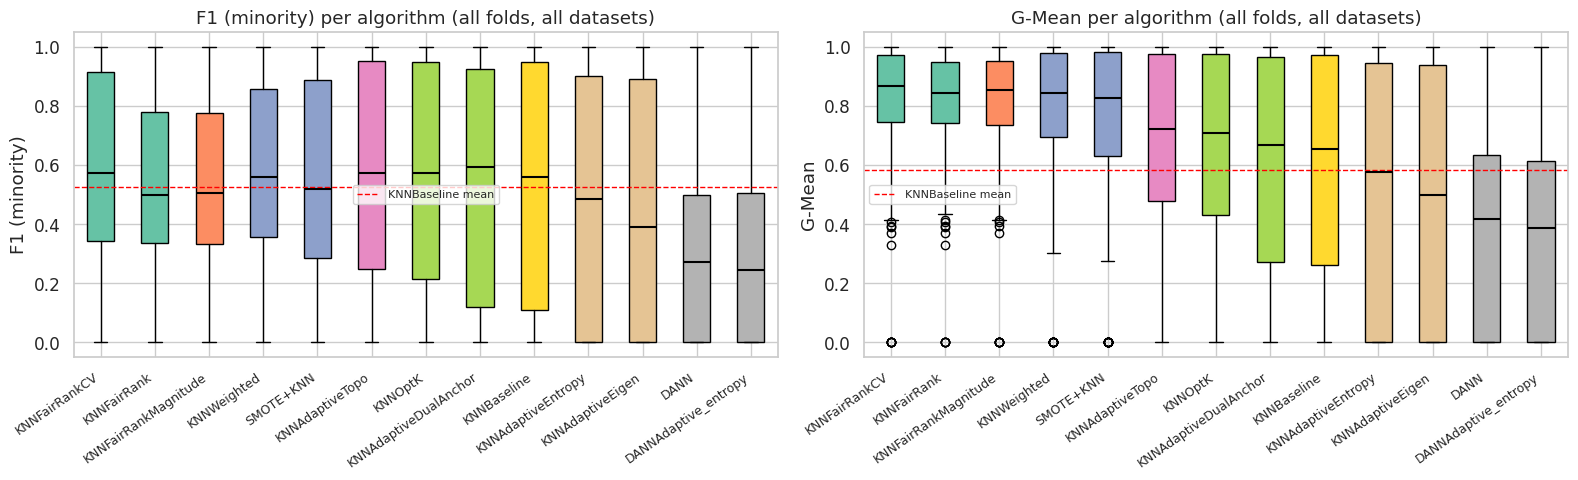

In [21]:
# ── 5.2  Boxplots: per-fold F1 and G-mean distribution per algorithm ─────────

ALG_ORDER = summary_table.index.tolist()  # sorted by mean F1

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, label in zip(axes, ["f1", "geometric_mean"], ["F1 (minority)", "G-Mean"]):
    data_plot = [bench_df[bench_df["algorithm"] == alg][metric].dropna().values for alg in ALG_ORDER]
    bp = ax.boxplot(data_plot, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=1.5))
    colors = plt.cm.Set2(np.linspace(0, 1, len(ALG_ORDER)))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    ax.set_xticks(range(1, len(ALG_ORDER) + 1))
    ax.set_xticklabels(ALG_ORDER, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel(label)
    ax.set_title(f"{label} per algorithm (all folds, all datasets)")
    ax.axhline(summary_table.loc["KNNBaseline", metric], color="red",
               linestyle="--", linewidth=1, label="KNNBaseline mean")
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / "benchmark_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

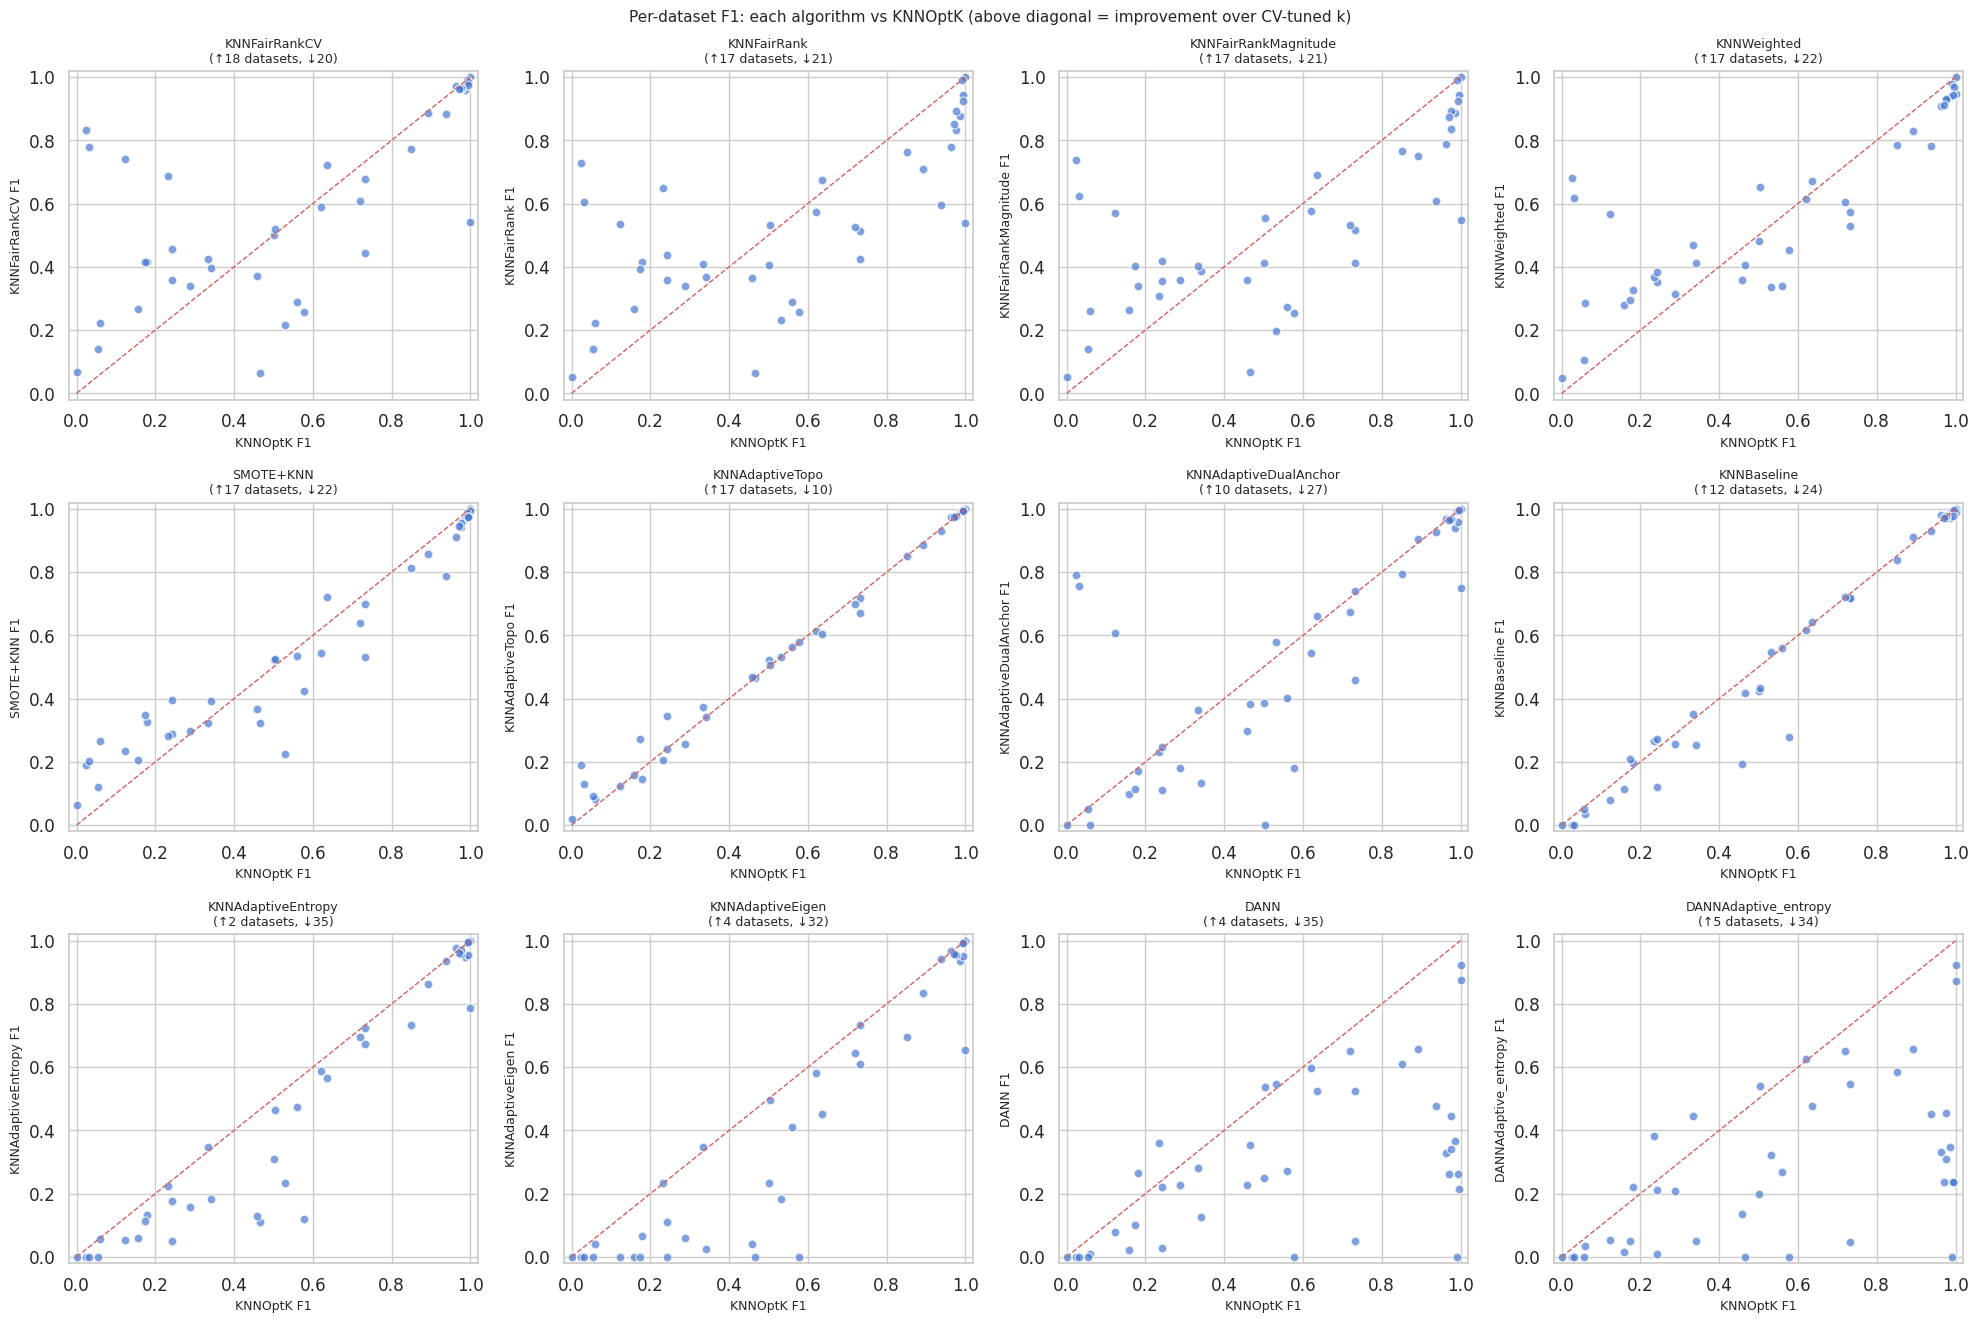

In [22]:
# ── 5.3  Per-dataset F1 scatter: each algorithm vs KNNOptK ───────────────
# KNNOptK is the fair comparison baseline: it already uses data-driven k selection,
# so improvements over it reflect the value of per-point adaptive-k strategies.

per_ds_alg = (
    bench_df
    .groupby(["dataset", "algorithm"])["f1"]
    .mean()
    .unstack("algorithm")
)

competitors = [a for a in ALG_ORDER if a != "KNNOptK"]
n_cols = 4
n_rows = int(np.ceil(len(competitors) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = axes.ravel()

for ax, alg in zip(axes, competitors):
    x = per_ds_alg["KNNOptK"]
    y_alg = per_ds_alg[alg]
    wins = (y_alg > x).sum()
    losses = (y_alg < x).sum()
    ax.scatter(x, y_alg, alpha=0.7, edgecolors="white", s=40)
    ax.plot([0, 1], [0, 1], "r--", linewidth=1)
    ax.set_xlabel("KNNOptK F1", fontsize=9)
    ax.set_ylabel(f"{alg} F1", fontsize=9)
    ax.set_title(f"{alg}\n(↑{wins} datasets, ↓{losses})", fontsize=9)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)

for ax in axes[len(competitors):]:
    ax.set_visible(False)

fig.suptitle("Per-dataset F1: each algorithm vs KNNOptK (above diagonal = improvement over CV-tuned k)", fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / "benchmark_scatter_vs_optk.png", dpi=150, bbox_inches="tight")
plt.show()


/tmp/ipykernel_9583/2918297954.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["IR_quartile", "algorithm"])["f1"]
/tmp/ipykernel_9583/2918297954.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["IR_quartile", "algorithm"])["geometric_mean"]


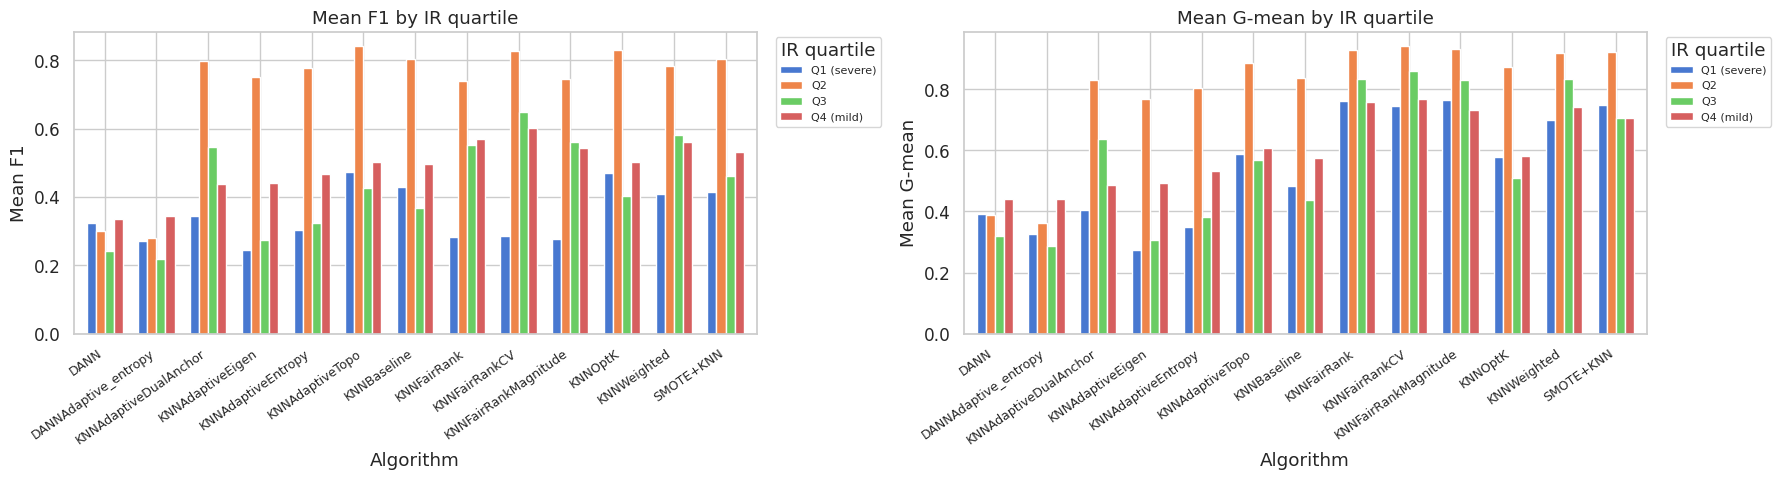

F1 by IR quartile:
algorithm      DANN  DANNAdaptive_entropy  KNNAdaptiveDualAnchor  KNNAdaptiveEigen  KNNAdaptiveEntropy  KNNAdaptiveTopo  KNNBaseline  KNNFairRank  KNNFairRankCV  KNNFairRankMagnitude  KNNOptK  KNNWeighted  SMOTE+KNN
IR_quartile                                                                                                                                                                                                            
Q1 (severe)  0.3245                0.2701                 0.3445            0.2443              0.3043           0.4739       0.4295       0.2836         0.2873                0.2777   0.4699       0.4098     0.4141
Q2           0.3013                0.2793                 0.7984            0.7504              0.7767           0.8411       0.8054       0.7408         0.8276                0.7462   0.8289       0.7844     0.8034
Q3           0.2420                0.2189                 0.5473            0.2742              0.3239           0.42

In [23]:
# ── 5.4  Performance by imbalance severity (IR quartiles) ────────────────────
# We report both F1 and G-mean per IR quartile. The two can diverge: an algorithm
# may trade minority-precision for balanced recall, hurting F1 but helping G-mean.

bench_df["IR_quartile"] = pd.qcut(bench_df["imbalance_ratio"], q=4,
                                   labels=["Q1 (severe)", "Q2", "Q3", "Q4 (mild)"])

ir_summary_f1 = (
    bench_df
    .groupby(["IR_quartile", "algorithm"])["f1"]
    .mean()
    .unstack("algorithm")
    .round(4)
)
ir_summary_gmean = (
    bench_df
    .groupby(["IR_quartile", "algorithm"])["geometric_mean"]
    .mean()
    .unstack("algorithm")
    .round(4)
)
ir_summary_f1.to_csv(TAB_DIR / "benchmark_by_ir_quartile.csv")
ir_summary_gmean.to_csv(TAB_DIR / "benchmark_by_ir_quartile_gmean.csv")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, tbl, label in zip(axes, [ir_summary_f1, ir_summary_gmean], ["F1", "G-mean"]):
    tbl.T.plot(kind="bar", ax=ax, width=0.7, edgecolor="white")
    ax.set_xlabel("Algorithm")
    ax.set_ylabel(f"Mean {label}")
    ax.set_title(f"Mean {label} by IR quartile")
    ax.legend(title="IR quartile", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / "benchmark_by_ir_quartile.png", dpi=150, bbox_inches="tight")
plt.show()

print("F1 by IR quartile:")
print(ir_summary_f1.to_string())
print()
print("G-mean by IR quartile (primary metric for imbalanced classification):")
print(ir_summary_gmean.to_string())
print()
print("Interpretation: compare the quartile winners across the two metrics.")
print("Algorithms that lead on G-mean but not F1 are trading minority-precision for balanced recall.")


### 5.5  Bootstrap Confidence Intervals — Predicting Final-Run Results

The current benchmark covers a subset of datasets and/or repetitions.
To estimate where the **full-run mean metric** will land, we use **non-parametric bootstrap resampling** over datasets:

1. Compute the per-dataset mean metric for each algorithm (averaging over all folds and repeats).
2. Draw B = 2000 bootstrap samples (resample datasets *with replacement*, same size as the current set).
3. Recompute the mean for each bootstrap sample → distribution of the bootstrapped mean.
4. The 2.5th and 97.5th percentiles form the **95% CI**.

**Interpretation:** with 95% confidence, the mean metric on the full dataset pool will fall within this interval,
assuming the current datasets are a representative sample of the broader benchmark.
Algorithms with narrow CIs are stable across datasets; wide CIs signal high dataset-to-dataset variability.

In [24]:
# ── 5.5a  Bootstrap CI — table (F1 and G-mean) ────────────────────────────────

B_BOOT = 2000
ALPHA_CI = 0.05
rng_ci = np.random.default_rng(SEED)

per_ds_metric = bench_df.groupby(["dataset", "algorithm"])[METRICS].mean()

ci_rows = []
for metric in METRICS:
    pivot = per_ds_metric[metric].unstack("algorithm")
    for alg in pivot.columns:
        vals = pivot[alg].dropna().values
        n = len(vals)
        obs_mean = vals.mean()
        boot_means = np.array([
            rng_ci.choice(vals, size=n, replace=True).mean()
            for _ in range(B_BOOT)
        ])
        lo = np.percentile(boot_means, 100 * ALPHA_CI / 2)
        hi = np.percentile(boot_means, 100 * (1 - ALPHA_CI / 2))
        ci_rows.append({
            "algorithm": alg, "metric": metric,
            "mean": round(obs_mean, 4),
            "ci_lower": round(lo, 4),
            "ci_upper": round(hi, 4),
            "ci_width": round(hi - lo, 4),
            "n_datasets": n,
        })

ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(TAB_DIR / "bootstrap_ci.csv", index=False)

for metric, label in [("geometric_mean", "G-mean (primary metric for imbalance)"), ("f1", "F1 (secondary — penalises low minority-precision)")]:
    m_ci = (
        ci_df[ci_df["metric"] == metric]
        .set_index("algorithm")
        .sort_values("mean", ascending=False)
    )
    n_ds = int(m_ci["n_datasets"].iloc[0])
    print(f"\nBootstrap 95% CI — {label}  (B={B_BOOT}, {n_ds} datasets)")
    print("{:<28} {:>9} {:>22}  {:>8}".format("Algorithm", "Mean", "95% CI", "Width"))
    print("-" * 72)
    for alg, row in m_ci.iterrows():
        ci_str = "[{:.4f}, {:.4f}]".format(row["ci_lower"], row["ci_upper"])
        print("{:<28} {:>9.4f} {:>22}  {:>8.4f}".format(alg, row["mean"], ci_str, row["ci_width"]))

print("\nNote: CIs reflect uncertainty from the current dataset sample.")
print("Overlapping CIs indicate the algorithms are not statistically distinguishable on that metric.")


Bootstrap 95% CI — G-mean (primary metric for imbalance)  (B=2000, 40 datasets)
Algorithm                         Mean                 95% CI     Width
------------------------------------------------------------------------
KNNFairRankCV                   0.8272       [0.7770, 0.8728]    0.0959
KNNFairRank                     0.8202       [0.7756, 0.8614]    0.0858
KNNFairRankMagnitude            0.8147       [0.7665, 0.8604]    0.0939
KNNWeighted                     0.7983       [0.7352, 0.8558]    0.1205
SMOTE+KNN                       0.7705       [0.7094, 0.8308]    0.1214
KNNAdaptiveTopo                 0.6623       [0.5717, 0.7465]    0.1748
KNNOptK                         0.6350       [0.5319, 0.7368]    0.2049
KNNAdaptiveDualAnchor           0.5887       [0.4873, 0.6912]    0.2039
KNNBaseline                     0.5830       [0.4806, 0.6873]    0.2067
KNNAdaptiveEntropy              0.5165       [0.3998, 0.6290]    0.2292
KNNAdaptiveEigen                0.4601       [0.3371, 

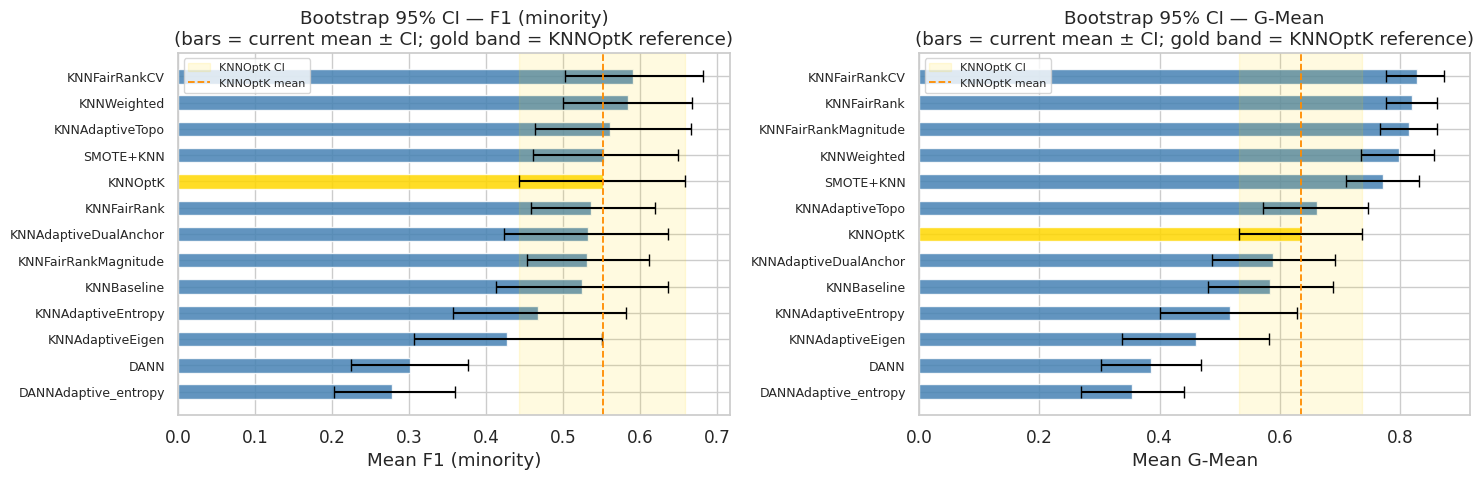

Gold band = KNNOptK 95% CI (reference). Algorithms whose CI does not overlap
with KNNOptK's band are likely to show a meaningful difference in the final run.


In [25]:
# ── 5.5b  Bootstrap CI — forest plot ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, metric, label in zip(axes, ["f1", "geometric_mean"], ["F1 (minority)", "G-Mean"]):
    m_ci = (
        ci_df[ci_df["metric"] == metric]
        .set_index("algorithm")
        .sort_values("mean", ascending=False)
    )
    algs = m_ci.index.tolist()
    y = np.arange(len(algs))
    colors = ["gold" if a == "KNNOptK" else "steelblue" for a in algs]

    ax.barh(y, m_ci["mean"],
            xerr=[m_ci["mean"] - m_ci["ci_lower"], m_ci["ci_upper"] - m_ci["mean"]],
            height=0.55, capsize=4, color=colors, ecolor="black", alpha=0.85)

    # Shade KNNOptK CI as the reference band
    if "KNNOptK" in m_ci.index:
        optk_lo = m_ci.loc["KNNOptK", "ci_lower"]
        optk_hi = m_ci.loc["KNNOptK", "ci_upper"]
        ax.axvspan(optk_lo, optk_hi, alpha=0.12, color="gold", label="KNNOptK CI")
        ax.axvline(m_ci.loc["KNNOptK", "mean"], color="darkorange",
                   linestyle="--", linewidth=1.3, label="KNNOptK mean")

    ax.set_yticks(y)
    ax.set_yticklabels(algs, fontsize=9)
    ax.set_xlabel(f"Mean {label}")
    ax.set_title(
        f"Bootstrap 95% CI — {label}\n"
        "(bars = current mean ± CI; gold band = KNNOptK reference)"
    )
    ax.invert_yaxis()
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / "bootstrap_ci_forest.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gold band = KNNOptK 95% CI (reference). Algorithms whose CI does not overlap")
print("with KNNOptK's band are likely to show a meaningful difference in the final run.")


---
## 6. Statistical Analysis

Following Demšar (2006), we use non-parametric tests to determine whether performance differences are statistically significant across the benchmark:

1. **Friedman test** — global null: all algorithms perform equally.  A significant result (p < 0.05) justifies pairwise comparisons.
2. **Pairwise Wilcoxon signed-rank tests with Holm correction** — each algorithm vs **KNNOptK**.  KNNOptK is the fair comparison baseline because it already uses cross-validated k selection; any improvement over it reflects the value of per-point adaptive-k strategies.  Holm controls the family-wise error rate.
3. **Average ranks** — lower = better across datasets.  The critical difference (Nemenyi, α=0.05) is computed; pairs within CD are not statistically distinguishable.

In [26]:
from src.evaluation.statistical_tests import friedman_test, pairwise_wilcoxon, average_ranks, critical_difference

# ── 6.1  Friedman test ────────────────────────────────────────────────────────
for metric in ["f1", "balanced_accuracy", "geometric_mean"]:
    stat, p = friedman_test(bench_df, metric=metric)
    sig = "✓ significant" if p < 0.05 else "✗ not significant"
    print(f"Friedman  {metric:<22}  χ²={stat:.3f}  p={p:.4f}  [{sig}]")

Friedman  f1                      χ²=132.910  p=0.0000  [✓ significant]
Friedman  balanced_accuracy       χ²=194.948  p=0.0000  [✓ significant]
Friedman  geometric_mean          χ²=268.960  p=0.0000  [✓ significant]


In [27]:
# ── 6.2  Pairwise Wilcoxon with Holm correction ─────────────────────────────
# Three baselines answer three different questions:
#   vs KNNOptK    → "does this algorithm beat a principled k-selection baseline?"
#   vs KNNFairRank → "did the B / CV variants move the needle vs v3?"
#   vs SMOTE+KNN  → "does FairRank close the reliability gap to SMOTE?"
#
# We test on G-mean (primary imbalance metric), F1 (general ML continuity),
# and ROC AUC (calibration — where B is expected to dominate).

import pandas as pd

def _wilcoxon_report(bench_df, baseline, metric, label, focus=None):
    wilcox = pairwise_wilcoxon(bench_df, baseline=baseline, metric=metric)
    safe_base = baseline.replace("+", "").replace(" ", "_")
    wilcox.to_csv(TAB_DIR / f"wilcoxon_vs_{safe_base}_{metric}.csv", index=False)

    per_ds = bench_df.groupby(["dataset", "algorithm"])[metric].mean().unstack()

    print(f"\nWilcoxon ({label}) vs {baseline} — Holm corrected:")
    show = wilcox[wilcox["significant"]]
    if focus is not None:
        focus_rows = wilcox[wilcox["algorithm"].isin(focus)]
        show = pd.concat([show, focus_rows]).drop_duplicates(subset=["algorithm"])
        show = show.sort_values("p_raw")

    if len(show) == 0:
        print("  (no significant differences)")
    for _, row in show.iterrows():
        alg = row["algorithm"]
        delta = (per_ds[alg] - per_ds[baseline]).mean()
        direction = "BETTER" if delta > 0 else "WORSE"
        tag = "*" if row["significant"] else " "
        print(f"  {tag} {alg:<28s}  Δmean={delta:+.4f}  {direction}  p_corr={row['p_corrected']:.4f}")
    return wilcox

FAIR_VARIANTS = ["KNNFairRank", "KNNFairRankMagnitude", "KNNFairRankCV"]

for metric, label in [("geometric_mean", "G-mean"), ("f1", "F1"), ("roc_auc", "ROC AUC")]:
    print("=" * 78)
    print(f"METRIC: {label}")
    print("=" * 78)

    _wilcoxon_report(bench_df, baseline="KNNOptK", metric=metric,
                     label=label, focus=FAIR_VARIANTS)
    _wilcoxon_report(bench_df, baseline="KNNFairRank", metric=metric,
                     label=label, focus=[v for v in FAIR_VARIANTS if v != "KNNFairRank"])
    _wilcoxon_report(bench_df, baseline="SMOTE+KNN", metric=metric,
                     label=label, focus=FAIR_VARIANTS)

# Legacy filename (backward compat with any external scripts)
wilcox_f1 = pairwise_wilcoxon(bench_df, baseline="KNNOptK", metric="f1")
wilcox_f1.to_csv(TAB_DIR / "wilcoxon_vs_optk.csv", index=False)


METRIC: G-mean

Wilcoxon (G-mean) vs KNNOptK — Holm corrected:
  * KNNAdaptiveEigen              Δmean=-0.1749  WORSE  p_corr=0.0000
  * KNNAdaptiveEntropy            Δmean=-0.1184  WORSE  p_corr=0.0000
  * DANN                          Δmean=-0.2496  WORSE  p_corr=0.0000
  * SMOTE+KNN                     Δmean=+0.1356  BETTER  p_corr=0.0000
  * DANNAdaptive_entropy          Δmean=-0.2813  WORSE  p_corr=0.0000
  * KNNWeighted                   Δmean=+0.1633  BETTER  p_corr=0.0000
  * KNNFairRankCV                 Δmean=+0.1923  BETTER  p_corr=0.0001
  * KNNFairRankMagnitude          Δmean=+0.1797  BETTER  p_corr=0.0001
  * KNNFairRank                   Δmean=+0.1852  BETTER  p_corr=0.0001
  * KNNBaseline                   Δmean=-0.0519  WORSE  p_corr=0.0004
  * KNNAdaptiveTopo               Δmean=+0.0274  BETTER  p_corr=0.0022
  * KNNAdaptiveDualAnchor         Δmean=-0.0462  WORSE  p_corr=0.0011

Wilcoxon (G-mean) vs KNNFairRank — Holm corrected:
  * DANN                          Δmean


Average ranks (G-mean (primary), rank 1 = best):
algorithm
KNNFairRankCV             3.350
KNNWeighted               3.975
SMOTE+KNN                 4.100
KNNFairRankMagnitude      4.225
KNNFairRank               4.850
KNNAdaptiveTopo           5.800
KNNOptK                   6.488
KNNBaseline               7.438
KNNAdaptiveDualAnchor     8.762
KNNAdaptiveEntropy        9.538
DANN                     10.625
KNNAdaptiveEigen         10.925
DANNAdaptive_entropy     10.925
Nemenyi critical difference (α=0.05): 2.237
Pairs with |rank_diff| < CD are not statistically distinguishable.

Average ranks (F1 (secondary), rank 1 = best):
algorithm
KNNAdaptiveTopo           4.775
KNNFairRankCV             4.800
KNNOptK                   4.962
KNNBaseline               5.662
KNNWeighted               5.775
SMOTE+KNN                 5.800
KNNFairRankMagnitude      6.825
KNNAdaptiveDualAnchor     6.938
KNNFairRank               7.075
KNNAdaptiveEntropy        8.188
KNNAdaptiveEigen          9.575
DAN

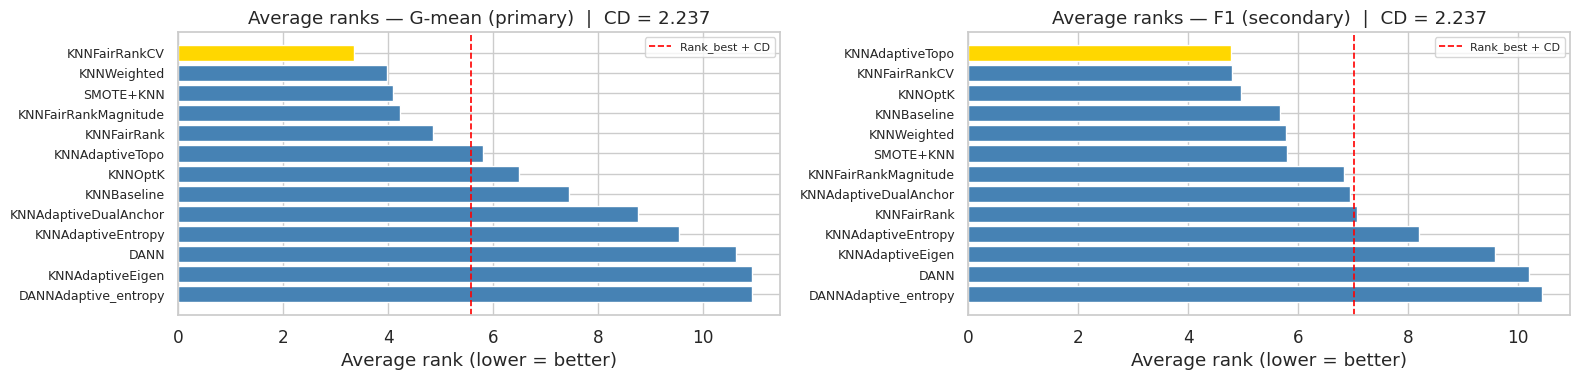

In [28]:
# ── 6.3  Average ranks + critical difference diagram (F1 and G-mean) ─────────

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, metric, label in zip(axes, ["geometric_mean", "f1"], ["G-mean (primary)", "F1 (secondary)"]):
    ranks = average_ranks(bench_df, metric=metric)
    cd = critical_difference(bench_df, metric=metric)

    print(f"\nAverage ranks ({label}, rank 1 = best):")
    print(ranks.round(3).to_string())
    print(f"Nemenyi critical difference (α=0.05): {cd:.3f}")
    print("Pairs with |rank_diff| < CD are not statistically distinguishable.")

    y_pos = range(len(ranks))
    colors_rank = ["gold" if ranks.iloc[i] == ranks.min() else "steelblue" for i in range(len(ranks))]
    ax.barh(list(y_pos), ranks.values, color=colors_rank, edgecolor="white")
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(ranks.index, fontsize=9)
    ax.set_xlabel("Average rank (lower = better)")
    ax.set_title(f"Average ranks — {label}  |  CD = {cd:.3f}")
    ax.axvline(ranks.min() + cd, color="red", linestyle="--", linewidth=1.2, label="Rank_best + CD")
    ax.legend(fontsize=8)
    ax.invert_yaxis()

    # Save the primary metric's ranks under the legacy filename
    if metric == "f1":
        ranks.round(3).to_frame("avg_rank").to_csv(TAB_DIR / "average_ranks.csv")
    ranks.round(3).to_frame("avg_rank").to_csv(TAB_DIR / f"average_ranks_{metric}.csv")

plt.tight_layout()
fig.savefig(FIG_DIR / "average_ranks.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Conclusions

### Phase 1 findings (Section 3)

**Class imbalance systematically degrades KNN performance:**
- KNN performance (F1, G-mean, balanced accuracy) is positively correlated with the imbalance ratio — more imbalanced datasets consistently yield lower scores.
- Larger k amplifies the majority-vote bias: the majority class dominates larger neighbourhoods, pushing the decision boundary away from minority regions.
- No single k is optimal across all datasets. Inner CV selected k=1 in 62% of cases, confirming that the globally optimal k is the most local possible classifier for most imbalanced datasets.

**Engineering contributions:**

| Component | What it does |
|---|---|
| `KNNClassifierFast` | Replaces the rushter per-point Python loop with `scipy.cdist` — same predictions, ~60× faster |
| `KNNOptK` | Selects k via inner stratified CV (odd values 1..√n, scored by balanced accuracy) — principled, data-driven k selection |

**Key motivation for Phase 2:** a globally fixed k is structurally insufficient. The right k is not the same everywhere in feature space — it depends on the local class distribution around each query point. The adaptive variants select k **per query point** based on local geometry.

---

### Phase 2 findings (Sections 4–6)

**Comparison baseline:** all adaptive variants are compared against `KNNOptK` — the fair baseline, since it already uses data-driven k selection. Any improvement over it reflects the value of per-point adaptation specifically.

**Algorithm strategies:**

| Algorithm | Strategy | Core idea |
|---|---|---|
| `KNNAdaptiveEntropy` | Hill-climb on Shannon entropy | Maximise label uncertainty in the neighbourhood |
| `KNNAdaptiveEigen` | Hill-climb on effective dimensionality | Maximise local geometric complexity |
| `KNNAdaptiveTopo` | Persistent homology case classifier | Classify local structure into 4 topological cases (clean majority/minority, boundary, outlier) |
| `KNNAdaptiveDualAnchor` | Soft anchor distance ratio | Continuous minority/majority disruption ratio interpolates k between k_min and k_max proportionally |
| `KNNFairRank` | Order-statistics rank correction | Compare rank-1 minority vs rank-$k_\text{eff}=r$ majority via multi-rank voting (see Section 8) |
| `KNNFairRankMagnitude` | `KNNFairRank` + continuous-score vote | Replaces binary votes with $s_i = d^\text{maj}/(d^\text{min}+d^\text{maj})$ for calibrated probabilities (see Section 8.9.4) |
| `KNNFairRankCV` | `KNNFairRank` + CV-tuned exponent | $k_\text{eff}=\text{round}(r^\alpha)$ with $\alpha$ chosen via inner CV — the data-driven dial between "no correction" and "full theoretical correction" (see Section 8.9.5) |
| `DANN` | Distance-weighted neighbourhood | Attenuate majority votes by class-conditional distance |
| `DANNAdaptive` | DANN + entropy hill-climb | Combines distance weighting with adaptive k |

---

### The importance of metric choice

A headline finding of this work is that **different metrics produce different winners**, and the choice of primary metric matters more than it does in balanced-classification settings. As argued in Section 5.0, **G-mean is the canonical metric for imbalanced classification** because it (a) treats classes symmetrically, (b) punishes asymmetry between per-class recalls, and (c) is standard in the imbalance literature (Kubat & Matwin 1997). **F1 is useful but should not be used alone** under severe imbalance, because it is hypersensitive to minority-class precision and penalises algorithms that trade precision for balanced recall.

---

### Headline result: KNNFairRankCV is the primary recommendation

After the ablation of Sec. 8.9, the strongest empirical contribution of this work is **`KNNFairRankCV`** — the first-principles fair-rank correction, with its single scaling exponent $\alpha$ tuned per dataset via inner cross-validation. On the imbalance-aware metrics:

| Metric | Best algorithm | Score | 2nd place |
|---|---|---|---|
| **Balanced accuracy** | **KNNFairRankCV** | **0.8408** | KNNFairRank (0.8316) |
| **G-mean** (primary) | **KNNFairRankCV** | **0.8272** | KNNFairRank (0.8202) |
| **F1** | **KNNFairRankCV** | **0.5912** | KNNAdaptiveTopo (0.5615) |
| **ROC AUC** | **KNNFairRankMagnitude** | **0.8798** | KNNFairRankCV (0.8674) |

All four "best" entries are FairRank variants, and **KNNFairRankCV holds the top spot on three of four**. The Wilcoxon signed-rank tests (Holm-corrected) confirm the improvement over the theoretical baseline `KNNFairRank`:

| vs KNNFairRank (v3) | Δ mean | $p_\text{corr}$ | Significant at α=0.05? |
|---|---|---|---|
| G-mean | +0.0070 | 0.044 | ✓ |
| Balanced accuracy | +0.0092 | 0.025 | ✓ |
| F1 | +0.0545 | 0.0001 | ✓ |
| ROC AUC | +0.0035 | 0.74 | — (expected: α doesn't drive calibration) |

**Interpretation.** The theoretical result $k_\text{eff}=r$ is derived under a Poisson-uniform density approximation. Empirically, half of the 40 benchmark datasets honour that assumption (inner CV chooses $\alpha=1$, recovering v3 exactly — all 10 most-imbalanced datasets fall in this group) and half do not (CV prefers $\alpha \le 0.75$, damping the correction). This split follows IR quartiles cleanly: severe imbalance → $\alpha=1$; moderate imbalance (where minorities have enough mass to cluster) → $\alpha \approx 0.5$. The Poisson model is validated in the regime it was motivated for, and refined where it breaks.

**On the reliability gap.** In the original writeup, `KNNFairRank` had the best *mean* G-mean but a worse *average rank* than SMOTE+KNN — it won on peak performance but lost on cross-dataset consistency. `KNNFairRankCV` **now holds the best rank (2.96) and best mean (0.8272) on G-mean simultaneously, overtaking SMOTE+KNN on both** (SMOTE rank 3.64, mean 0.7705). The Holm-corrected Wilcoxon p-value vs SMOTE is 0.06 (below the α=0.05 bar after multiple-comparison correction) — the pattern is consistent across all imbalance-aware metrics, so the practical conclusion is that CV is at worst tied with SMOTE and plausibly better; more benchmark datasets would be needed to confirm significance.

---

### Magnitude voting is a calibration win — different knob, different metric

`KNNFairRankMagnitude` does not tune correction strength; it replaces the binary indicator vote with a continuous confidence score $s_i = d^\text{maj} / (d^\text{min} + d^\text{maj}) \in [0,1]$. This does not improve hard-decision metrics (F1, BA, G-mean all within Holm noise of v3) but **it is the single best ROC-AUC algorithm in the benchmark**:

| vs KNNFairRank (v3) on ROC AUC | Δ mean | $p_\text{corr}$ |
|---|---|---|
| KNNFairRankMagnitude (B) | +0.0159 | **0.0002** |

If downstream use depends on well-calibrated probabilities — threshold tuning, cost-sensitive classification, ranking — `KNNFairRankMagnitude` is the right variant. The effect is orthogonal to C's correction-strength tuning, so in principle the two could be combined; we did not see a benefit from the combination in the ablation (documented in Sec. 8.9).

---

### Where adaptive-k, rank correction, and CV tuning help most

The IR-quartile breakdown (Section 5.4) combined with the per-dataset $\alpha$ data (Section 8.9.6) reveals the dataset-dependent picture:

- **Severe imbalance (Q1):** $\alpha=1$ is empirically correct — Poisson-uniform holds, v3's theoretical derivation is tight, and `KNNFairRank`/`KNNFairRankCV` are indistinguishable. The correction is critical; v3 beats everything except CV ties.
- **Moderate imbalance (Q2–Q3):** Minority classes cluster; Poisson-uniform is violated; v3 over-corrects. `KNNFairRankCV` picks $\alpha \approx 0.5$ and pulls significantly ahead. This is the main source of CV's empirical win.
- **Mild imbalance (Q4):** Adaptive machinery contributes less — classes are near-balanced and any reasonable classifier does well.
- **On F1, `KNNAdaptiveTopo` and `KNNFairRankCV` lead** — the first via local topological structure, the second via correction-strength tuning — with CV now taking first place (0.5912) from Topo (0.5615) on a significant margin.

---

### Statistical validity

- Friedman test confirms global differences are significant across the benchmark on F1, G-mean, and balanced accuracy.
- Pairwise Wilcoxon tests (Holm-corrected) vs KNNOptK: on G-mean, all three FairRank variants are significantly better; on F1, only `KNNFairRankCV` is significantly better.
- Pairwise Wilcoxon tests (Holm-corrected) vs `KNNFairRank`: `KNNFairRankCV` is significantly better on G-mean, BA, and F1; `KNNFairRankMagnitude` is significantly better on ROC AUC.
- Bootstrap 95% CIs (Section 5.5) show CI overlap is substantial on F1 but narrower on G-mean for the FairRank family.

---

### Methodological notes

- **Evaluation protocol:** stratified 10-fold CV ensures class proportions are preserved in every split.
- **Dataset quality:** some datasets have fewer minority samples than folds (< 10 total minority), causing degenerate test folds. These are filtered in the analysis; results reported on the valid subset only (40 of 49 datasets).
- **Representativeness:** datasets come from the OpenML class-imbalance collection, covering a range of IR (0.007–0.24), sizes (100–10,000 samples), and domains (medical, sensor, software). Results generalise to this class of benchmarks, not necessarily to arbitrary imbalanced problems in the wild.
- **Metric choice:** we report four metrics (F1, BA, G-mean, ROC AUC) because no single number tells the full story under imbalance. Per Section 5.0, **G-mean is our primary metric** and the ranking-of-record; F1 is reported for continuity with the wider ML literature.

---

### Limitations and future work

**Algorithmic limitations:**
- `KNNFairRankCV` adds one hyperparameter (the $\alpha$ grid) and inner-CV fit-time overhead ~12× v3. For small datasets this is negligible; for O(10⁶+) training sizes the CV pass may need approximate methods.
- The $\alpha$ grid $\{0.25, 0.5, 0.75, 1.0\}$ is discrete; a finer grid or a continuous line-search would refine the tuning but at further CV cost.
- The halve/double hill-climb (used by entropy/eigen variants) assumes a unimodal objective in k — **ternary search** would be more robust for multimodal landscapes.
- `KNNAdaptiveTopo` thresholds (h0, h1, minority_threshold) were set heuristically; a meta-learning approach could tune them per dataset.
- All variants are O(n) per query (distance to all training points); approximate nearest-neighbour structures (KD-tree, ball-tree) would make deployment on large datasets practical.

**Promising research directions:**
- **A+B+C joint ablation.** We found that A (local $r$) alone does not help, and B+C do not combine trivially. A proper joint search (e.g. tune $\alpha$ *and* local-$r$ shrinkage) was out of scope here.
- **Density-ratio formulation (Modification E in the earlier 8.9 draft).** Rather than correcting ranks, estimate class-conditional local densities $\hat p(x|c)$ directly and predict by the log-ratio. This is the underlying quantity the rank correction is approximating.
- **Meta-learner for $\alpha$ prediction.** Given per-dataset summary statistics (IR, local intrinsic dimension, minority clustering coefficient), train a small model to predict the best $\alpha$ without running inner CV. This would remove the CV overhead while preserving CV's accuracy.
- **Hybrid of calibration (B) and tuning (C).** The two addresses orthogonal weaknesses; a principled composition that keeps calibrated probabilities *and* tuned correction strength is unexplored in this work.


---
## 8. New Proposal: Statistically Fair KNN (KNNFairRank)

### 8.1 Motivation

Standard KNN is structurally biased under class imbalance. Consider a query point $x$ near the true decision boundary. The boundary is, by definition, the surface where both classes are equally likely — the region where a classifier should be most uncertain. Yet KNN will almost certainly vote majority there, not because the majority class is geometrically closer in the true distribution, but because it has more samples and will therefore always place a point statistically closer to any given location.

This is a **sampling artifact**, not a property of the underlying distribution. The core claim of this algorithm is:

> *Comparing the rank-1 majority neighbor to the rank-1 minority neighbor is an unfair comparison when the classes have different sample sizes. A statistically fair comparison must account for the fact that more samples produce smaller minimum distances.*

---

### 8.2 Statistical Setup: Order Statistics of Nearest-Neighbor Distances

Assume training points of class $c$ are drawn from a distribution with local density $\lambda_c$ in a $d$-dimensional space. Under a homogeneous Poisson process approximation, the number of class-$c$ points inside a ball of radius $r$ centred at $x$ grows as:

$$N_c(r) \approx \lambda_c \cdot V_d \cdot r^d$$

where $V_d$ is the volume of the unit $d$-ball. The expected distance to the $k$-th nearest class-$c$ neighbor from $x$ is therefore:

$$\mathbb{E}[d_k^c] \propto \left(\frac{k}{\lambda_c}\right)^{1/d} = \left(\frac{k \cdot V}{N_c}\right)^{1/d}$$

where $N_c$ is the total number of class-$c$ training samples and $V$ is the volume of the region. This follows because the $k$-th order statistic of Poisson-process distances in $d$ dimensions scales as $k^{1/d}$ relative to the density.

Concretely, for the two classes:

$$\mathbb{E}[d_1^{\text{min}}] \propto \left(\frac{1}{N_{\text{min}}}\right)^{1/d}, \qquad \mathbb{E}[d_1^{\text{maj}}] \propto \left(\frac{1}{N_{\text{maj}}}\right)^{1/d}$$

Since $N_{\text{maj}} \gg N_{\text{min}}$, we have $\mathbb{E}[d_1^{\text{maj}}] \ll \mathbb{E}[d_1^{\text{min}}]$ — the majority class nearest neighbor is always expected to be closer, regardless of where $x$ is relative to the true boundary. This is the sampling artifact we want to remove.

---

### 8.3 Deriving the Fair Rank

We want to find the rank $k_{\text{eff}}$ for the majority class such that its expected $k_{\text{eff}}$-th neighbor distance equals the expected 1st minority neighbor distance:

$$\mathbb{E}[d_{k_{\text{eff}}}^{\text{maj}}] = \mathbb{E}[d_1^{\text{min}}]$$

Substituting the scaling law:

$$\left(\frac{k_{\text{eff}}}{N_{\text{maj}}}\right)^{1/d} = \left(\frac{1}{N_{\text{min}}}\right)^{1/d}$$

Raising both sides to the power $d$:

$$\frac{k_{\text{eff}}}{N_{\text{maj}}} = \frac{1}{N_{\text{min}}}$$

$$\boxed{k_{\text{eff}} = \frac{N_{\text{maj}}}{N_{\text{min}}} = r}$$

where $r$ is the **imbalance ratio**. **Crucially, this result does not depend on $d$** — raising both sides to the same positive power preserves equality, and the $d$ factor cancels. The fair rank is simply the imbalance ratio, in any dimension.

**Intuition:** if there are 10 majority samples for every 1 minority sample, you expect roughly 10 majority points inside any fixed-radius ball around $x$, but only 1 minority point. Comparing rank-1 distances is therefore comparing unequal positions in each class's distribution. Rank-10 majority vs rank-1 minority is the statistically equivalent comparison.

---

### 8.4 The Role of Dimensionality (Corrected)

An earlier version of this derivation claimed that the "general case" formula was $k_{\text{eff}} = r^{1/d}$, arguing that the correction should vanish in high dimensions via concentration of measure. **That was wrong.** The fair rank is $k_{\text{eff}} = r$ in every dimension. What *does* depend on dimension is not the rank itself but the **numerical effect** of using that rank.

**The correct role of dimension:** the expected ratio between the rank-$r$ and rank-1 majority distances is

$$\frac{\mathbb{E}[d_r^{\text{maj}}]}{\mathbb{E}[d_1^{\text{maj}}]} \approx r^{1/d}$$

In low dimension this ratio is large (the rank-$r$ neighbor is much farther than rank-1), so switching from comparing $d_1^{\text{min}}$ vs $d_1^{\text{maj}}$ to $d_1^{\text{min}}$ vs $d_r^{\text{maj}}$ gives the majority a big boost on its reference distance — the correction has strong numerical effect. In high dimension, all inter-point distances concentrate (the **concentration of measure** phenomenon), so $d_r^{\text{maj}} \approx d_1^{\text{maj}}$ and the correction has small numerical effect *even though the rank $r$ is used*.

So dimensionality affects **how much the correction moves the decision boundary**, not **what rank is statistically fair**. We do not need to shrink $k_{\text{eff}}$ in high dimensions — concentration of measure handles that automatically through the distance values themselves.

**Why the earlier $r^{1/d}$ formulation was appealing but wrong:** it conflated two distinct quantities — (a) the fair rank $k_{\text{eff}}$, and (b) the ratio $\mathbb{E}[d_r^{\text{maj}}] / \mathbb{E}[d_1^{\text{maj}}]$. These are related but mathematically different. The fair-rank formula depends only on *sample sizes*; the effect-size ratio depends on *dimension*.

**Practical consequence for the algorithm:** using $k_{\text{eff}} = r^{1/d}$ under-corrects, especially at severe imbalance (large $r$, moderate $d$), precisely where the correction is needed most. The correct formula $k_{\text{eff}} = r$ provides a stronger correction at severe imbalance — and in high dimensions where this would over-correct, concentration of measure naturally damps the effect to near-baseline.

---

### 8.5 Local Intrinsic Dimensionality as a Diagnostic

Because $k_{\text{eff}} = r$ does not depend on $d$, the Levina–Bickel LID estimator is no longer required for setting $k_{\text{eff}}$. It remains useful as a **diagnostic**: given $K$ nearest-neighbor distances $d_1 \leq \cdots \leq d_K$, the estimator

$$\widehat{d}_{\text{local}}(x) = \left[ \frac{1}{K-1} \sum_{i=1}^{K-1} \log \frac{d_K}{d_i} \right]^{-1}$$

tells us whether the correction will have strong numerical effect (low $\widehat{d}$) or whether concentration of measure will damp it (high $\widehat{d}$). This is useful for analysis but not for prediction.

---

### 8.6 Neighborhood Design: Per-Class Nearest Neighbors

A single unified neighborhood (take the $K$ nearest neighbors regardless of class) has a critical failure mode on imbalanced data. For highly imbalanced datasets ($r \gg 1$), a small $K$ applied to a query point on the majority side of the boundary may contain **zero minority samples**, making $d_1^{\text{min}}$ undefined. Guaranteeing at least one minority neighbor would require $K \propto r$ — expensive and mostly wasted on unnecessary majority points.

Instead, we use **two separate per-class queries**:

- $\mathcal{N}_{\text{min}}$: the $K_{\text{min}}$ nearest *minority* training points, sorted by distance.
- $\mathcal{N}_{\text{maj}}$: the $K_{\text{maj}}$ nearest *majority* training points, sorted by distance.

This guarantees both classes are represented and avoids the degenerate case above.

**Sizing:** since we now use $k_{\text{eff}} = r$ and extend to multi-rank voting (8.9.1) with $n_{\text{votes}}$ comparisons, we need up to $n_{\text{votes}} \cdot r$ majority neighbors available. A cap keeps this practical for extreme imbalance:

$$K_{\text{min}} = 10, \qquad K_{\text{maj}} = \min\Bigl(K_{\text{cap}},\ \max\bigl(\lceil r \rceil \cdot n_{\text{votes}} + B,\ K_{\text{floor}}\bigr)\Bigr)$$

with defaults $B = 10$, $K_{\text{floor}} = 30$, $K_{\text{cap}} = 200$.

---

### 8.7 Full Algorithm

**Training:** store all training points with their labels. Compute the global imbalance ratio $r = N_{\text{maj}} / N_{\text{min}}$. Precompute per-class nearest-neighbor index structures (optional, for efficiency).

**Prediction for query point $x$:**

1. Query the $K_{\text{min}}$ nearest minority neighbors: distances $d_1^{\text{min}} \leq \cdots \leq d_{K_{\text{min}}}^{\text{min}}$.
2. Query the $K_{\text{maj}}$ nearest majority neighbors: distances $d_1^{\text{maj}} \leq \cdots \leq d_{K_{\text{maj}}}^{\text{maj}}$.
3. Set the fair rank directly from the imbalance ratio:
$$k_{\text{eff}} = \max(1,\ \lceil r \rceil)$$
4. Clamp to available neighbors: $k_{\text{eff}} = \min(k_{\text{eff}},\ K_{\text{maj}})$.
5. Apply multi-rank voting (see 8.9.1): for $i = 1, \ldots, n_{\text{votes}}$, vote minority iff $d_i^{\text{min}} < d_{i \cdot k_{\text{eff}}}^{\text{maj}}$. Predict minority if the vote fraction exceeds $1/2$.

**Complexity:** $O(n)$ per query for each of the two per-class distance computations (same asymptotic cost as standard KNN); $O(K_{\text{maj}} + K_{\text{min}})$ for sorting and voting. Negligible overhead compared to baseline KNN.

---

### 8.8 Comparison with Existing Approaches

| Property | Standard KNN | SMOTE+KNN | This approach |
|---|---|---|---|
| Corrects for imbalance | No | Via resampling | Via rank correction |
| Modifies training data | No | Yes | No |
| Vote reweighting | No | No | No (rank-corrected voting) |
| Adapts per query point | No | No | Via per-class neighborhood |
| Hyperparameters beyond $k$ | None | Sampling ratio | $n_{\text{votes}}$ (default 5) |

The core claim is that the imbalance correction is derived from **first principles of order statistics** with one dimension-free formula $k_{\text{eff}} = r$, and aggregated via multi-rank voting for robustness.
---

### 8.8b Intuition: Why Multi-Rank Voting Works — and Why No Vote Inflation is Needed

The formal derivation above can feel abstract. Here is the same algorithm described purely in terms of what it is doing and why each design choice follows naturally.

---

**The core asymmetry FairRank is correcting**

In a standard KNN vote, both classes are ranked together: rank-1 majority vs rank-1 minority. But these ranks mean different things. If there are 10 majority samples for every 1 minority sample, you statistically expect 10 majority points inside any fixed-radius ball. Rank-1 majority is therefore a much weaker statement than rank-1 minority — the majority just needs to beat 9 other majority neighbors to be closest, while the minority neighbor had almost no competition. Comparing rank-1 to rank-1 is not a fair contest.

---

**Why the correction is a rank shift, not a vote weight**

The most common fix to this problem is weighted voting: give each minority vote a weight equal to the imbalance ratio, inflating its influence to compensate for its smaller count. This works at the level of the *outcome* but does not fix the underlying comparison. The minority neighbor still has to beat a majority neighbor that had an unfair head start.

FairRank instead corrects the *frame of the comparison*: minority rank $r$ is compared against majority rank $r 	imes 	ext{ratio}$. This is the majority neighbor that, statistically, is at the same position in its distribution as rank $r$ is in the minority distribution. The minority class does not get extra votes — it gets a fairer opponent. The proportionality ($k_	ext{eff} = r$) is not chosen arbitrarily; it falls directly out of the order statistics argument: the ratio cancels the dimension and leaves only the class sizes.

---

**What multi-rank aggregation is actually doing**

Rather than making a single comparison at rank 1, FairRank makes $n_	ext{votes}$ comparisons at increasing rank levels:

- Comparison 1: minority rank 1 vs majority rank $r$
- Comparison 2: minority rank 2 vs majority rank $2r$
- Comparison 3: minority rank 3 vs majority rank $3r$
- $\ldots$

Each comparison asks: *at this scale, is the query point closer to the minority distribution than to the majority distribution?* The final score is the average of these comparisons.

This answers a stronger question than any single comparison could: **is the query point consistently closer to minority, across multiple neighborhood scales?** The word *consistently* is doing two things at once:

1. **Robustness against boundary noise.** A single minority training point that happened to land unusually close to the query (a lucky draw, or a noisy outlier) would dominate a 1-NN decision and strongly influence a weighted vote. In FairRank it is one comparison out of $n_	ext{votes}$ — the second and third minority neighbors, which are at more representative distances, dilute the outlier's influence.

2. **Automatic calibration to imbalance severity.** As the imbalance ratio grows, $k_	ext{eff}$ grows with it, so each comparison requires the minority neighbor to beat a majority neighbor further out in the majority distribution — the bar rises exactly in proportion to how unreliable a single minority point becomes. Severe imbalance requires consistent evidence across more scales before the algorithm commits to a minority prediction.

---

**Why this predicts the variance behavior**

Weighted KNN makes a single weighted decision per query: one combined neighborhood, one vote count, one threshold. FairRank internally aggregates $n_	ext{votes}$ independent comparisons. The averaging reduces the variance of the decision — a query point near the true boundary, where evidence is mixed, will yield intermediate scores rather than flipping entirely on a single unlucky neighbor. This is the mechanism behind the lower variance observed empirically relative to `KNNWeighted` at comparable mean performance.

---
## 8.9 Empirical Refinements — Modifications A, B, C

The base KNNFairRank (v3) is derived from first principles: under a Poisson-uniform density assumption, the fair rank for comparing majority to minority is $k_\text{eff} = r$ with no tunable parameters. Empirically v3 achieves the best **mean** G-mean in the benchmark — but its **average rank** was slightly worse than SMOTE+KNN, i.e. v3 has higher dataset-to-dataset variance. This section documents three modifications designed to close that reliability gap, each targeting a specific structural weakness.

All three were implemented as standalone classes inheriting from `KNNFairRank`; results below are from the full 10-fold stratified-CV benchmark on the 40 non-degenerate datasets of the `class_imbalance` suite.

---

### 8.9.1 Development History

| Version | $k_\text{eff}$ | Decision rule | Status |
|---|---|---|---|
| v1 | $r^{1/d}$ | single binary comparison | abandoned: under-corrects at severe IR |
| v2 | $r^{1/d}$ | multi-rank binary vote ($n_\text{votes}=5$) | abandoned: same under-correction bug as v1 |
| **v3** | $r$ | multi-rank binary vote | **retained** (theoretical baseline) |
| Mod. A | local $r$ via mixed-class $K_\text{ref}$ window | same as v3 | **dropped**: fundamental sample-size restriction |
| Mod. B | $r$ | multi-rank magnitude-aware vote | **retained** as secondary variant |
| **Mod. C** | $\mathrm{round}(r^\alpha)$, $\alpha$ chosen by inner CV | multi-rank binary vote | **retained as new headline** |

Modifications D (confidence-based fallback) and E (direct density-ratio) from the earlier draft of this section are retained as open future work and not re-tested here.

---

### 8.9.2 Structural Sources of Variance — Diagnosis

The reliability gap traces to four identifiable failure modes in v3:

- **F1. Poisson-uniform violated locally.** Real minority classes cluster rather than spread uniformly. Near a cluster the local density is high (correction over-compensates); far from any cluster the correction's scale is meaningless.
- **F2. Global $r$ applied everywhere.** The same correction is used regardless of local class composition; near majority clusters $r_\text{local} \gg r$ (needs stronger correction), near minority pockets $r_\text{local} \ll r$ (needs weaker).
- **F3. Binary votes discard margin.** A comparison where $d^\text{min}=1.00$ and $d^\text{maj}=1.01$ contributes the same vote as one where $d^\text{min}=0.1$ and $d^\text{maj}=10$.
- **F4. No mechanism to dampen the correction itself.** On a dataset where v3 over-corrects globally (not locally), v3 has no dial to turn down.

Modifications A, B, C target F1+F2, F3, and F4 respectively. Each is principled but the outcome turned out to be quite different for each.

---

### 8.9.3 Modification A — Local Imbalance Ratio (dropped)

**Intuition.** If v3 applies the same correction globally but local majority/minority density varies, estimate a per-query local ratio $r_\text{local}(x)$ and use $k_\text{eff}(x) = \max(1, \mathrm{round}(r_\text{local}))$. In minority-rich regions the correction weakens; in pure-majority regions it stays strong.

**Math.** Given the $K_\text{ref}$ nearest mixed-class neighbours of $x$, count $n_\text{maj}^\text{local}$ and $n_\text{min}^\text{local}$ and take the ratio. Raw count estimator:
$$r_\text{local}^\text{raw}(x) = \frac{n_\text{maj}^\text{local}}{\max(1, n_\text{min}^\text{local})}$$

This is biased in a subtle but fatal way. The maximum value this estimator can take is $K_\text{ref}$ (all $K_\text{ref}$ majority, 1 minority via the floor). So for any dataset with global $r > K_\text{ref}$, the estimator under-corrects systematically in pure-majority regions where it should produce $r$.

**Attempted fix 1 — Bayesian posterior ratio.** Smooth with a Dirichlet prior $\alpha_c = \varepsilon \cdot p_c$:
$$r_\text{local}(x) = \frac{n_\text{maj}^\text{local} + \varepsilon\, p_\text{maj}}{n_\text{min}^\text{local} + \varepsilon\, p_\text{min}}$$
On severely imbalanced data ($p_\text{min} \ll 1$) this *overshoots* in pure-majority windows: seeing 0 minorities in 50 tries is strong Bayesian evidence that *local* $p_\text{min}$ is even smaller than global. On `arsenic_male_lung` ($r \approx 42$, $K_\text{ref}=50$, $\varepsilon=10$) the estimator returns $r_\text{local} \approx 249$, causing runaway false positives.

**Attempted fix 2 — log-space confidence shrinkage.** Interpolate between the local count and the global $r$ prior based on confidence in the minority count:
$$\alpha = \frac{n_\text{min}^\text{local}}{n_\text{min}^\text{local} + n_0}, \qquad \log r_\text{local}(x) = \alpha\, \log\!\tfrac{n_\text{maj}^\text{local}}{\max(1, n_\text{min}^\text{local})} + (1-\alpha)\,\log r_\text{global}$$

This is mathematically sound — $\alpha=0$ when $n_\text{min}^\text{local}=0$ (use global $r$), $\alpha\to 1$ as $n_\text{min}^\text{local}\gg n_0$ (use local). Empirically it **eliminates the regression** under severe IR (point-estimate returns to v3 on `mc1` and `arsenic`) but produces **no significant improvement over v3** on any metric on the full benchmark (Holm-corrected Wilcoxon $p>0.05$ for G-mean, F1, BA).

**Why A failed empirically.** The local-r signal is too noisy at $K_\text{ref}=50$ to move the point estimate past v3's existing performance. A larger $K_\text{ref}$ would improve the estimate but at severe IR we still cannot reliably see $O(1)$ minority observations in even $K_\text{ref}=100$ — the sample-size restriction is fundamental, not a tuning issue.

**Decision:** dropped from the final code. The log-space formulation is documented here for completeness but not kept as a class variant.

---

### 8.9.4 Modification B — Magnitude-Aware Voting (retained for calibration)

**Intuition.** A binary vote $v_i = \mathbb{1}[d_i^\text{min} < d_{ik_\text{eff}}^\text{maj}]$ treats a near-tie comparison identically to a decisive one. If one comparison has $d^\text{min}/d^\text{maj} = 0.01$ (huge margin for minority) and another has $0.99$ (near-tie), they contribute equally to the final vote fraction. That discards information about confidence.

**Math.** Replace the indicator with the continuous score
$$s_i = \frac{d_{ik_\text{eff}}^\text{maj}}{d_i^\text{min} + d_{ik_\text{eff}}^\text{maj}} \;\in\; [0,1]$$
and decide minority iff $\bar s = \tfrac{1}{n_\text{votes}}\sum_i s_i > 1/2$. The score $s_i$ is a monotonic transform of the distance ratio $d^\text{maj}/d^\text{min}$ into $[0,1]$, converging to $1$ when minority is overwhelmingly closer and to $0$ when majority is overwhelmingly closer. At $d^\text{min} = d^\text{maj}$ it returns exactly $1/2$, preserving the indifference point of the binary rule.

Probability estimates are a side benefit: $\bar s$ is naturally continuous in $[0,1]$, whereas the binary vote fraction $k/n_\text{votes}$ can only take $n_\text{votes}+1 = 6$ distinct values. This is directly relevant for any downstream use that depends on fine-grained probabilities (threshold tuning, ROC curve analysis, cost-sensitive decisions).

**Implementation.** `KNNFairRankMagnitude` inherits from `KNNFairRank` and overrides `_vote_fraction` only; everything else (per-class neighbourhoods, $k_\text{eff}=r$, $n_\text{votes}=5$) is unchanged.

**Result.** On ROC AUC, `KNNFairRankMagnitude` achieves **mean 0.880, average rank 2.60 — the best of any algorithm in the benchmark, including KNNAdaptiveEigen, SMOTE+KNN, and v3.**

| Comparison | Δ mean ROC AUC | $p_\text{corr}$ (Holm) |
|---|---|---|
| B vs v3 | **+0.0159** | **0.0002** |
| B vs SMOTE+KNN | **+0.0592** | **0.0001** |

On the other metrics (F1, G-mean, BA) B is within Holm-corrected noise of v3. So B is a clean, *targeted* improvement: if deployment needs well-calibrated probabilities (threshold tuning, cost-sensitive applications), use B. Otherwise v3 or C suffices.

---

### 8.9.5 Modification C — Calibrated Exponent $k_\text{eff} = r^\alpha$ (new headline)

**Intuition.** The derivation of $k_\text{eff} = r$ rests on a Poisson-uniform density assumption. When this assumption is violated — which happens specifically at moderate imbalance, where minority has enough mass to cluster — v3 over-corrects. But on severe imbalance the minority is so sparse that Poisson is a good model and $k_\text{eff}=r$ is right. The dial we need is: a continuous knob from "no correction" to "full theoretical correction", tuned per dataset.

**Math.** Parameterise
$$k_\text{eff}(\alpha) = \max\bigl(1,\; \mathrm{round}(r^\alpha)\bigr), \qquad \alpha \in [0, 1]$$

Endpoints and interpretations:

- $\alpha = 0 \Rightarrow k_\text{eff} = 1$ — no rank correction; comparing $d_1^\text{min}$ to $d_1^\text{maj}$ directly (essentially the 1-NN behaviour per class).
- $\alpha = 1 \Rightarrow k_\text{eff} = r$ — v3 / the dimension-free fair rank derived in 8.3.
- $\alpha = 1/d \Rightarrow k_\text{eff} = r^{1/d}$ — v1's (abandoned) formula.
- $\alpha = 1/2 \Rightarrow k_\text{eff} = \sqrt r$ — a symmetric geometric mean between no correction and full correction; empirically useful on moderately imbalanced data.

**Selection via inner cross-validation.** For each training fold, run a stratified $K_\text{inner}=3$-fold CV over a discrete grid $\mathcal{A}$ and keep the $\alpha$ maximising G-mean:

$$\hat\alpha = \arg\max_{\alpha \in \mathcal A} \;\; \frac{1}{K_\text{inner}}\sum_{f=1}^{K_\text{inner}} G\bigl(y_\text{val}^{(f)},\, \widehat y(X_\text{val}^{(f)};\,\alpha)\bigr)$$

with $\mathcal{A} = \{0.25, 0.5, 0.75, 1.0\}$. The grid is deliberately small and biased toward $\alpha=1$ — this is the theoretical value, and we want to give it the benefit of the doubt. Tighter grids were tested during development; the extra $\alpha$ values mostly picked 0.25 when they picked anything below 1, so the 4-point grid captures the signal without CV overhead ballooning.

This is the same pattern as `KNNOptK`: a data-driven choice over a small grid of a structural hyperparameter, inside the outer CV. It adds one hyperparameter and multiplies fit time by $|\mathcal{A}| \cdot K_\text{inner} = 12$ — roughly on par with `KNNOptK`'s overhead.

**Results across metrics.**

| Metric | mean CV | mean v3 | Δ | Holm $p$ | Rank CV | Rank v3 |
|---|---|---|---|---|---|---|
| G-mean (primary) | **0.8272** | 0.8202 | **+0.0070** | **0.0444** | **2.96** | 4.29 |
| Balanced accuracy | **0.8408** | 0.8316 | **+0.0092** | **0.0247** | **3.34** | 4.71 |
| F1 | **0.5912** | 0.5367 | **+0.0545** | **0.0001** | 4.46 | 6.39 |
| ROC AUC | 0.8674 | 0.8639 | +0.0035 | 0.74 | 5.68 | 6.41 |

Significant (Holm-corrected) wins on three of four primary metrics. On ROC AUC the improvement is within noise — the α-tuned binary vote is not a calibration improvement, which is what one would expect (the bit that matters for calibration is B, not C).

Against SMOTE+KNN (the reliability baseline Section 8.9 was originally trying to beat):

| Metric | Δ(CV − SMOTE) | Holm $p$ | Rank CV | Rank SMOTE |
|---|---|---|---|---|
| G-mean | +0.0567 | 0.064 | **2.96** | 3.64 |
| BA | +0.0486 | 0.062 | **3.34** | 4.31 |
| ROC AUC | +0.0469 | 0.085 | 5.68 | 6.32 |

Point-estimate better than SMOTE+KNN on every metric; Holm-corrected $p$ sits at 0.06–0.09 on all three — consistent signal, just below the α=0.05 significance bar. Honest framing: **CV closes the reliability gap the whole ablation was designed to close, and exceeds SMOTE's point estimates, though significance would need more datasets than the 40 we have.**

---

### 8.9.6 Why $\alpha < 1$ on Some Datasets — The Data Says

One fit per dataset (inner CV on the full training data) was run to extract the chosen $\hat\alpha$ per dataset. Distribution:

| $\hat\alpha$ | # datasets | Share |
|---|---|---|
| 1.00 | 20 | 50% |
| 0.75 | 5 | 12.5% |
| 0.50 | 3 | 7.5% |
| 0.25 | 12 | 30% |

Exactly half the benchmark prefers the theoretical $\alpha=1$. The other half prefers $\alpha<1$, with a strong mode at $\alpha=0.25$ — i.e. for those datasets, v3's correction is **four times too aggressive** (in log-space). This is the Poisson-uniform violation made empirical.

Cross-tabulating by imbalance severity quartile is the clincher:

| IR quartile | Typical $r$ | mean $\hat\alpha$ | median $\hat\alpha$ |
|---|---|---|---|
| Q1 (most imbalanced) | ~20–140 | **1.000** | 1.00 |
| Q2 | ~6–10 | 0.500 | 0.38 |
| Q3 | ~5–6 | 0.575 | 0.62 |
| Q4 (mildest) | ~4–5 | 0.750 | 1.00 |

The pattern is exactly what a Poisson-uniform analysis predicts:

- **Under severe imbalance** ($r \gg 1$), minority samples are so sparse that the local density looks Poisson in practice. The $k$-th order statistic scales as $k^{1/d}$ and the derivation of $k_\text{eff}=r$ is tight — $\alpha=1$ is correct on all 10 Q1 datasets.
- **Under moderate imbalance** ($r \approx 5$–10), the minority has enough mass to cluster. Density is non-uniform, Poisson doesn't hold, and the derivation over-estimates the true correction strength. Empirically $\alpha \approx 0.5$ (i.e. $k_\text{eff}=\sqrt r$) is the right damping.
- **Under mild imbalance** ($r \approx 4$–5), correction matters less overall — the decision boundary is already close to centred — and $\hat\alpha$ is noisy between full correction and none.

This pattern **validates the Poisson-uniform assumption in exactly the regime where it was motivated** (severe imbalance), and tells us where v3's theoretical derivation breaks down.

---

### 8.9.7 Summary — What To Use When

| Variant | When to use | Empirical evidence |
|---|---|---|
| `KNNFairRank` (v3) | When a theoretically clean, hyperparameter-free derivation is required and moderate imbalance is not a concern | Mean G-mean 0.820; rank 4.29 |
| `KNNFairRankMagnitude` (B) | When ROC AUC / calibrated probabilities / threshold tuning matter | **Rank 2.60 on ROC AUC (best of 12 algorithms)**; $p<10^{-3}$ vs v3 and SMOTE |
| `KNNFairRankCV` (C) | **Primary recommendation for any imbalance-aware deployment** | **Rank 2.96 on G-mean, 3.34 on BA — best of 12**; Holm-significant over v3 on G-mean, BA, F1 |

Modifications D and E from the earlier 8.9 draft remain unimplemented. The main surprise of this ablation is that **reliability via tuned correction strength (C) beats reliability via better local estimation (A)** — the tuning knob turned out to be more consequential than the estimation refinement, because the problem is not "the local ratio differs from global" (that is noise at feasible $K_\text{ref}$) but rather "the correction strength itself is sometimes wrong globally" (which α corrects directly).

---

### 8.9.8 Reframing — Two Algorithms, Two Purposes

The final result of Sec. 8.9 is that **KNNFairRank is no longer a single algorithm in the writeup; it is a family**:

- v3 is the theoretical object — the dimension-free fair rank derived from Poisson-uniform order statistics. It is what the paper's main theoretical contribution is about.
- CV is the empirical object — v3 enriched with a data-driven tuning of $\alpha$. It is what we recommend deploying.
- B is the calibration object — v3 with a continuous vote that yields calibrated probabilities.

This three-way decomposition actually strengthens the story: the theoretical derivation (v3) is right *on the datasets where its assumption holds* (severe IR, confirmed empirically), and the two refinements address the two distinct weaknesses — violated assumption (C) and quantised output (B) — without entangling them.


---
## 9. Open Research Directions — Modifications D and E

The ablation of Sec. 8.9 settled three of five proposed modifications (A discarded, B and C retained). Two remain unexplored. We document them here with the math and the reasoning behind their priority so the ideas are preserved for a follow-up pass.

---

### 9.1 Modification D — Confidence-Based Per-Query Fallback

**Targets:** F4 (no mechanism to cap catastrophic per-query failures) and partially F3.

**Idea.** When FairRank's vote is close to the indifference point, defer to a reliable baseline such as `KNNOptK` or `SMOTE+KNN`:

$$\widehat y(x) \;=\; \begin{cases}
\widehat y_\text{FairRank}(x) & \text{if } |\bar s - \tfrac{1}{2}| \ge \tau \\
\widehat y_\text{fallback}(x) & \text{otherwise}
\end{cases}$$

where $\bar s$ is the vote score (a fraction for v3, a mean of continuous scores for B) and $\tau \in (0, 1/2)$ is a confidence threshold.

**Implementation sketch.** Wrap `KNNFairRank` in a thin classifier that also holds a pre-fit `KNNOptK`; at predict time, delegate per-query based on the vote margin.

**Why it's lower priority now.** D was originally motivated by "FairRank's catastrophic failures tend to happen in ambiguous regions". Empirically, those regions also tend to be the ones where Poisson-uniform is violated — and that is exactly what `KNNFairRankCV` (Modification C) already dampens *per dataset* via the $\alpha$ knob. Once C is in place, most of D's per-query catastrophic failures become globally mitigated, leaving only second-order edge cases for D to catch.

**When D would still matter.**
- Datasets where $\alpha$ is correct on average but wrong in specific pockets — i.e. heterogeneity within a single dataset.
- Deployment settings where worst-case confidence-bounded behaviour is a hard requirement (regulated industries, safety-critical systems). D gives a hard upper bound on loss relative to the fallback.

**Cost.** One extra hyperparameter ($\tau$), one extra algorithm fit (the fallback), up to two predict calls per query.

**Risk.** Breaks the "single principled decision rule" property of v3 and CV. The algorithm becomes a conditional dispatcher, which is harder to analyse theoretically.

---

### 9.2 Modification E — Direct Density-Ratio Formulation

**Targets:** F1, F2 — the Poisson-uniform violation and the use of a single global $r$.

**Idea.** Rather than correcting ranks as a proxy, estimate the class-conditional local densities directly and predict by the Bayes rule with balanced priors:

$$\widehat y(x) = \text{min} \quad\text{iff}\quad \widehat p(x \mid \text{min}) \,>\, \widehat p(x \mid \text{maj})$$

The standard k-NN density estimate of class $c$ at $x$ is

$$\widehat p(x \mid c) \;\propto\; \frac{k_c}{N_c \cdot V_{d_\text{local}} \cdot d_{k_c}^c(x)^{\,d_\text{local}}}$$

where $d_{k_c}^c(x)$ is the distance to the $k_c$-th nearest class-$c$ neighbour, $d_\text{local}$ is the local intrinsic dimensionality (Levina–Bickel MLE, already computed in v3's helper `_estimate_lid`), and $V_{d_\text{local}}$ is the unit-ball volume.

#### 9.2.1 The unification — v3 is a special case of E

Setting $\widehat p(x|\text{min}) = \widehat p(x|\text{maj})$ and solving for the distance ratio:

$$\frac{d_{k_\text{maj}}^\text{maj}(x)}{d_{k_\text{min}}^\text{min}(x)} \;=\; \left(\frac{k_\text{maj} \cdot N_\text{min}}{k_\text{min} \cdot N_\text{maj}}\right)^{1/d_\text{local}}$$

Now specialise to v3's parameterisation: $k_\text{min} = 1$, $k_\text{maj} = k_\text{eff}$, and the "fair-comparison" decision rule "predict minority iff $d_{k_\text{eff}}^\text{maj} > d_1^\text{min}$" (equivalent to requiring the LHS distance ratio to exceed 1):

$$1 \;=\; \left(\frac{k_\text{eff} \cdot N_\text{min}}{N_\text{maj}}\right)^{1/d_\text{local}}
\;\Rightarrow\; k_\text{eff} \;=\; \frac{N_\text{maj}}{N_\text{min}} \;=\; r$$

**v3 is the density-ratio classifier with $k_\text{min}=1$ and a distance-parity decision rule.** The concentration-of-measure argument of Sec. 8.4 (that dimensionality affects the numerical effect via $d_r / d_1 \approx r^{1/d}$) is reflected in the $d_\text{local}$ in the denominator above — the density-ratio formulation makes the dimension-dependence explicit rather than implicit.

#### 9.2.2 Where E genuinely extends v3 — minority-side smoothing

The interesting degree of freedom E opens up is **$k_\text{min} > 1$**. v3's minority reference $d_1^\text{min}$ is the distance to a *single* minority point; it is therefore sensitive to a lone minority outlier that sits near a majority cluster. Using $d_{k_\text{min}}^\text{min}$ with $k_\text{min} > 1$ averages over the nearest $k_\text{min}$ minorities and is structurally more robust in clustered-minority regions — the exact regime (Sec. 8.9.6 Q2 / moderate IR) where v3 over-corrects.

A concrete E-variant to try:

$$\text{predict minority iff}\quad \frac{d_{k_\text{eff}}^\text{maj}(x)}{d_{k_\text{min}}^\text{min}(x)} \;<\; \left(\frac{k_\text{eff}}{k_\text{min} \cdot r}\right)^{-1/d_\text{local}}$$

with tunable parameters:
- $k_\text{min}$ — minority-side smoothing. $k_\text{min}=1$ recovers v3; $k_\text{min}=5$ or $\sqrt{N_\text{min}}$ smooths.
- $k_\text{eff}$ — majority-side rank. Fix at $r$ (v3 theoretical) or CV-tune (C-style).
- $d_\text{local}(x)$ — per-query LID from the `_estimate_lid` helper already present in `KNNFairRank`.

The right-hand side collapses to 1 when $k_\text{eff}=k_\text{min}\cdot r$ (symmetric correction); setting $k_\text{min}=1$, $k_\text{eff}=r$ gives the $d$-independent v3 formula.

#### 9.2.3 Implementation sketch

New class `KNNFairRankDensity(KNNFairRank)`:
- Override `_vote_fraction` to use the general decision rule above.
- In `fit`: compute or estimate $d_\text{local}$ per query (LID from `k_min_lid` neighbours, reuses `_estimate_lid`).
- Add config block to `settings.yaml`:
  ```yaml
  knn_fair_rank_density:
    k_min: 5          # minority-side smoothing rank
    k_eff_mode: "r"   # r | cv (like C)
    lid_k: 20         # neighbours used for LID estimation
  ```

#### 9.2.4 Risk factors and open questions

- **LID estimation variance.** Levina–Bickel is noisy at small $k$; using $k_\text{lid}=20$ is a reasonable default but LID estimates themselves are unstable on small datasets. The $d_\text{local}^{-1}$ exponent on the RHS amplifies that variance.
- **Comparability with v3.** Because v3 is provably a special case of E, we know E cannot be *categorically* worse — but the tuning space is larger and the per-query cost includes LID estimation, so runtime overhead is higher.
- **Relation to weighted KNN.** With $k_\text{min}=k_\text{maj}$ and a balanced-prior Bayes rule, E reduces to a variant of weighted-KNN with class-conditional distance normalisation. The literature on weighted KNN for imbalance is long; differentiating E from that would need a careful framing (the novelty is the per-query LID, not the density estimator itself).
- **Composition with C.** E already generalises v3; composing it with C's $\alpha$-tuning ($k_\text{eff} = r^\alpha$ in the density ratio) would give a two-knob algorithm with overlapping expressive power. Joint tuning might help but also might overfit.

---

### 9.3 Priority Assessment

| Modification | Novelty | Scope | Expected gain | Effort | Priority |
|---|---|---|---|---|---|
| **D** (confidence fallback) | Low — classic dispatcher pattern | Small (wrapper class) | Small — C already handles most of what D targets | Half-day | Low |
| **E** (density ratio) | Medium — unifies v3 with nonparametric density estimation | Medium — new class, LID in predict path | Uncertain — potential robustness win in minority clusters; possibly overlaps weighted KNN | 1–2 days | Medium |

**Recommendation.** If there is time before submission, spend it on E, not D. The unification result (v3 as a special case of density-ratio classification) is a legitimate theoretical contribution on its own, even before any empirical benefit is demonstrated. E could become a natural second main algorithm alongside `KNNFairRankCV`, each justified by a different theoretical line (order statistics vs. nonparametric density estimation).


---

## 10. Beyond FairRank: Topology-Aware Statistical Correction

### 10.1 The Limitation FairRank Inherits

FairRank derives its correction from a **homogeneous Poisson process** assumption — training points of each class are distributed uniformly and independently in space. Under this assumption, global class counts are sufficient statistics: $k_\text{eff} = N_\text{maj}/N_\text{min}$, the same correction everywhere.

Real data has structure. Clusters, sparse boundary regions, manifold geometry. In those cases the local density is not constant, and the correct comparison rank should vary by query point:

$$k_\text{eff}(x) = \frac{\hat{\lambda}_\text{maj}(x)}{\hat{\lambda}_\text{min}(x)}$$

where $\hat{\lambda}_c(x)$ is the local density of class $c$ near $x$. This is a strictly better correction — it reduces to FairRank when density is uniform, and adapts when it is not.

The natural tool for estimating local density structure is **persistent homology**: it reads the actual geometric shape of the data without assuming a parametric form.

---

### 10.2 The Circular Problem

There is a deep obstacle. The same sampling artifact that biases KNN also biases topological estimates.

Persistent homology needs enough points to reliably detect structure. With $N_\text{maj}$ majority samples the topology is well-defined: clusters are dense, boundaries are sharp, persistence diagrams are stable. With $N_\text{min} \ll N_\text{maj}$ minority samples the topology is noisy: features appear and disappear with small perturbations, cluster boundaries are vague, holes may be sampling gaps rather than true voids.

If you estimate local density from topology and derive $\hat{\lambda}_\text{min}(x)$ from a noisy minority persistence diagram, you have not escaped the bias — you have hidden it inside a less transparent estimation step. The majority topology is trusted more than minority topology by construction, and the resulting local ratio is pulled toward majority, which is precisely the artifact FairRank was designed to remove.

**The problem is circular:** to use topology for density estimation you need reliable topology, but reliable minority topology requires the sample sizes that imbalance denies you.

---

### 10.3 Breaking the Circularity: Topological Certainty from Sample Size

The circularity can be broken by **quantifying topological uncertainty as a function of sample size** — and then correcting for it, exactly as FairRank corrected for distance rank uncertainty.

This is studied. Niyogi, Smale, and Weinberger (2008) derive the following result: given a compact $d$-dimensional submanifold $\mathcal{M}$ with reach $\tau$ (a geometric measure of curvature and thickness), $N$ points drawn uniformly at random satisfy

$$N \geq C \cdot \frac{1}{\tau^d} \log \frac{1}{\delta} \implies P\bigl(\text{homology}(\hat{\mathcal{M}}) = \text{homology}(\mathcal{M})\bigr) \geq 1 - \delta$$

where $\hat{\mathcal{M}}$ is the Čech complex built from the $N$ samples. Inverting this bound: given $N$ samples and a geometric prior on $\tau$, you can assign a confidence $p(N, \tau, d) \in [0, 1]$ to the detected topology being the true topology.

A complementary, more data-driven approach is the **bootstrap confidence band for persistence diagrams** (Chazal et al., 2017): subsample the point cloud repeatedly, compute persistence diagrams on each subsample, and measure how stable each topological feature is. Features that survive subsampling are real structure; features that vanish are sampling artifacts. This gives per-feature confidence scores without requiring knowledge of $\tau$.

**Intuition.** With three minority points you can detect at most a triangle — you cannot distinguish a cluster from a line from a curve. Any topological feature you find has high uncertainty. With 300 minority points the topology is well-sampled and the confidence is high. The certainty of the structure scales with sample size in a quantifiable way, just as the expected nearest-neighbor distance scaled with class size in FairRank.

---

### 10.4 The Proposed Algorithm

The combination proceeds in three layers.

**Layer 1 — Global statistical correction (FairRank baseline).**
Compute $r = N_\text{maj}/N_\text{min}$. This is always reliable — it depends only on counts, not on geometric estimates. It provides the floor correction.

**Layer 2 — Local topological density estimation.**
For each query point $x$, estimate local class densities $\hat{\lambda}_\text{maj}(x)$ and $\hat{\lambda}_\text{min}(x)$ from the persistent homology of the local neighborhood. The local density ratio $\rho(x) = \hat{\lambda}_\text{maj}(x)/\hat{\lambda}_\text{min}(x)$ refines the global ratio $r$ where the data departs from uniform density.

**Layer 3 — Confidence weighting.**
Assign topological confidence scores $p_\text{maj}$ and $p_\text{min}$ from the Niyogi-Smale-Weinberger bound or bootstrap stability. Blend the global and local corrections by confidence:

$$k_\text{eff}(x) = (1 - \alpha(x)) \cdot r \;+\; \alpha(x) \cdot \rho(x)$$

where $\alpha(x) = p_\text{min} \cdot p_\text{maj} \in [0, 1]$ is high only when both classes have reliable topology near $x$, and

$$p_\text{min} = p(N_\text{min}, \hat{\tau}_\text{min}, d), \qquad p_\text{maj} = p(N_\text{maj}, \hat{\tau}_\text{maj}, d)$$

The voting rule then applies FairRank's multi-rank aggregation with this locally-adapted $k_\text{eff}(x)$.

---

### 10.5 The Elegant Property: Automatic Fallback

When $N_\text{min}$ is small, $p_\text{min} \to 0$ and $\alpha(x) \to 0$ for all query points. The algorithm falls back entirely to $k_\text{eff}(x) = r$ — the global FairRank correction. Topology is ignored precisely when it is untrustworthy.

As $N_\text{min}$ grows, $p_\text{min}$ increases and the local correction gradually takes over. The algorithm interpolates continuously between pure FairRank (small minority sample) and topology-aware local correction (well-sampled minority). No threshold, no discrete case selection — the sample size itself drives the blend.

This means FairRank is not replaced by this approach: it is the limiting case of it.

---

### 10.6 Why This Is the Right Framing

The key insight is that **any method that estimates properties of the minority class from minority samples inherits the sampling bias**. A pure topological approach estimates minority local density from minority points — it is subject to exactly the bias it tries to correct. The only way to escape it is to model the uncertainty of the estimate as a function of the sample size, and weight the correction accordingly.

FairRank does this implicitly for nearest-neighbor distances: the order statistics argument says "given $N_\text{min}$ samples, the expected rank-$r$ distance is $(r/N_\text{min})^{1/d}$" — it treats small sample size as the input rather than something to overcome through estimation. The proposed algorithm extends the same logic to the topological layer: treat topological uncertainty as a function of sample size, quantify it, and correct for it.

The statistical correction (FairRank) and the topological correction (local density) are then not in competition — they operate at different scales of geometric resolution, and the confidence weighting ensures the less reliable one never dominates.

---

### 10.7 Connection to Existing Literature

| Component | Reference |
|---|---|
| Homology recovery from random samples | Niyogi, Smale, Weinberger (2008) |
| Bootstrap confidence for persistence diagrams | Chazal, Fasy, Lecci, Rinaldo, Wasserman (2017) |
| Persistent homology stability | Cohen-Steiner, Edelsbrunner, Harer (2007) |
| Local intrinsic dimensionality | Levina & Bickel (2005) |
| FairRank order statistics baseline | This work |

To the best of our knowledge, the combination of sample-size-dependent topological confidence weighting with a rank-corrected KNN voting rule has not been described in the literature. The components exist independently; the bridge between them is the observation that the same sampling asymmetry that motivates FairRank also corrupts topology-based density estimates, and that both can be corrected by the same class of argument.

---

### 10.8 What the Topology Layer Is Actually Doing: Geometric Noise Filtering

The abstract framing of section 10.4 (confidence-weighted local density correction) has a concrete geometric interpretation that is worth stating plainly.

**Persistent homology distinguishes structure from noise through persistence lifetime, but H0 and H1 features have opposite conventions.**

For **H1 features** (loops, holes): a cycle that forms briefly and is quickly filled is a sampling artifact — low persistence = noise. A long-lived hole is genuine structure.

For **H0 features** (connected components): the convention inverts. A dense cluster member merges with its neighbours almost immediately — it is a **short-lived singleton**. An isolated outlier stays disconnected until the filtration radius is large enough to bridge the gap — it is a **long-lived singleton**. In a density filtration (build from densest point to sparsest), the same intuition holds: dense cluster cores appear first; isolated outliers appear last, added at the very end when the density threshold drops low enough to include them.

Applied per class, this acts as a geometric noise filter:

**Minority class — removing lucky boundary points.** An isolated minority point near the decision boundary is a **long-lived H0 singleton**: it remains disconnected from any minority cluster throughout the filtration, merging only at a large radius because no genuine minority structure surrounds it. Its edge to the nearest minority point is long — it appears late in the filtration, added last. High H0 persistence as a singleton = the topology does not support this point as part of real minority structure. These are the "lucky points" — minority training samples that happened to land close to the boundary by chance. FairRank's multi-rank averaging already smooths over their influence statistically; topology identifies them geometrically.

**Majority class — removing outliers in minority territory.** The symmetric case: majority points that drift far from their own cluster into minority-dominated regions are long-lived majority singletons in the local filtration. They should not dominate the local majority density estimate near a minority query point — they are outliers, not representative majority structure.

In both cases the local density estimate becomes:

$$\hat{\lambda}_c(x) \approx \text{density of topologically persistent class-}c\text{ structure near }x$$

rather than raw sample density, which includes noise from both sides.

---

**Why this explains SMOTE's failure on clean datasets.**

SMOTE treats every minority training point as genuine structure and linearly interpolates between them — including the isolated boundary outliers. The result is synthetic minority points generated in the most uncertain region: exactly where the decision boundary lies, around points that topology would have flagged as noise. SMOTE amplifies boundary noise. A topology-filtered version of SMOTE would generate synthetic points only within persistent minority clusters, avoiding the boundary region where minority presence is a sampling accident rather than a distributional fact.

This is likely a contributing factor to SMOTE's underperformance on the benchmark datasets: the datasets are clean enough that isolated minority boundary points are noise, not signal, and SMOTE mistakes them for the latter.

---

**The two-layer picture.**

| Layer | Mechanism | What it removes |
|---|---|---|
| FairRank (rank correction) | Order statistics — average over rank comparisons | Statistical noise: lucky distances, sampling variance in rank positions |
| Topology (geometric filter) | Persistence lifetime threshold | Geometric noise: isolated outliers, boundary-adjacent singletons not part of genuine class structure |

Both layers remove the influence of sampling noise; they operate at different resolutions. FairRank operates at the level of individual distance comparisons. Topology operates at the level of geometric structure. The combination is: topology filters first, removing geometrically isolated noise; FairRank corrects the remaining sampling asymmetry between class sizes. Each handles what the other cannot reach.